## Preparation

### Libraries import & metadata storage definitions

In [1]:
import os
import numpy as np
import torch
from time import time

from torch.optim import AdamW, lr_scheduler
from torch.nn import CrossEntropyLoss
from torchvision import datasets, transforms, models
from torch.utils.data import Dataset, DataLoader, ConcatDataset

import matplotlib.pyplot as plt

In [2]:
checkpoint_dir = "task_files_2/checkpoints"
graph_dir = "task_files_2/regnet_graphs"
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(graph_dir, exist_ok=True)

### Dataset download & instantiation

В работе рассматривается задача классификации изображений, для которой используются модель семейства RegNet версии RegNet_X_3_2_GF и датасет CIFAR-100. 

Датасет CIFAR-100 содержит 60 000 цветных изображений (50 000 в подсете train и 10 000 в подсете test) размерности 32х32 пикселя, каждое из которых соотносится ровно с 1 из 100 классов. Классы сбалансированы: каждый класс представлен 600 изображениями.

Модель для ускорения обучения инициализируется весами, предобученными на датасете [ImageNet](https://www.kaggle.com/competitions/imagenet-object-localization-challenge/overview) со следующими метриками точности:
- acc1: 78.364,
- acc5: 93.992
с дальнейшей адаптацией архитектуры под CIFAR-100.

In [3]:
def make_train_loader_cifar100(data_dir: str, 
                               batch_size: int = 256, 
                               num_workers: int = 4):
    transforms_train = transforms.Compose([
        transforms.Resize(32),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.5071, 0.4867, 0.4408],
            std=[0.2675, 0.2565, 0.2761]
        )
    ])
    
    cifar100_train = datasets.CIFAR100(
        root=data_dir,
        train=True,
        download=True,
        transform=transforms_train
    )
    
    return DataLoader(
        cifar100_train,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )

def make_val_loader_cifar100(data_dir: str, 
                             batch_size: int = 256, 
                             num_workers: int = 4):
    transforms_val = transforms.Compose([
        transforms.Resize(32),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.5071, 0.4867, 0.4408],
            std=[0.2675, 0.2565, 0.2761]
        )
    ])
    
    cifar100_val = datasets.CIFAR100(
        root=data_dir,
        train=False,
        download=True,
        transform=transforms_val
    )
    
    return DataLoader(
        cifar100_val,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )

In [4]:
dataset_dir_cifar100 = "/home/user/Desktop/o-net-experiments/regnetx_imagenet/D:/cifar100"
dataset_name = "CIFAR-100"
n_classes = 100
batch_size = 128
num_workers = 4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", torch.cuda.get_device_name() if device.type == "cuda" else device.type)

Device: NVIDIA GeForce GTX 1650


In [5]:
print("[ ] Creating train & val dataloaders for CIFAR-100...")
train_loader = make_train_loader_cifar100(dataset_dir_cifar100, batch_size, num_workers)
val_loader = make_val_loader_cifar100(dataset_dir_cifar100, batch_size, num_workers)
print("[V] Train & val ataloaders for CIFAR-100 created")

[ ] Creating train & val dataloaders for CIFAR-100...
[V] Train & val ataloaders for CIFAR-100 created


### Model download & instantiation

In [6]:
def adapt_model_cifar100(model, 
                         n_classes: int,
                         in_channels: int = 3, 
                         out_channels: int = 32,
                         kernel_size: int = 3,
                         stride: int = 1, 
                         padding: int = 1,
                         bias: bool = False):
    model.stem[0] = torch.nn.Conv2d(
        in_channels = in_channels, out_channels = out_channels, 
        kernel_size=kernel_size, stride=stride, padding=padding, 
        bias=bias
    )
    model.fc = torch.nn.Linear(model.fc.in_features, n_classes)


In [7]:
print("[ ] Instantiating model...")
regnetx_3_2 = models.regnet_x_3_2gf(weights=models.RegNet_X_3_2GF_Weights.DEFAULT, progress=True)
adapt_model_cifar100(regnetx_3_2, n_classes)
regnetx_3_2.to(device)
regnetx_3_2_name = "RegNetX_3_2"
print("[V] Model instantiated and adapted for CIFAR-100")

[ ] Instantiating model...
[V] Model instantiated and adapted for CIFAR-100


In [8]:
max_lr = 0.01
weight_decay = 0.001

criterion = CrossEntropyLoss()
optimizer = AdamW(regnetx_3_2.parameters(), lr=max_lr, weight_decay=weight_decay)
scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)

### Common key functions

In [9]:
def plot_metric(trains: list, 
                tests: list, 
                epochs: int, 
                model_name: str = "model",
                dataset_name: str = "dataset",
                metric_name: str = "metric",
                graph_dir: str = "graphs"):
    
    fig, ax = plt.subplots(figsize=(20, 6))
    ax.plot(
        [i+1 for i in range(epochs)],
        trains, 
        "b.-", alpha=0.6, lw=0.3, ms=0.8,
        label="train " + metric_name
    )
    ax.plot(
        [i+1 for i in range(epochs)],
        tests, 
        "r.-", alpha=0.8, lw=0.3,
        label="test " + metric_name
    )
    ax.set(
        title=f"{model_name} {metric_name} on {dataset_name} for {epochs} epochs",
        xlabel="epochs", xlim=(-1, epochs+1), xticks=[i for i in range(0, epochs+1, 5)],
        ylabel=metric_name
    )
    ax.grid(True, alpha=0.3, zorder=0)
    ax.legend()

    plt.savefig(os.path.join(graph_dir, f"regnet_{metric_name}_{epochs}epochs.png"))

In [10]:
def plot_final_losses_accs(train_losses: list, 
                           test_losses: list, 
                           train_accs: list, 
                           test_accs: list, 
                           model_name: str = "model",
                           dataset_name: str = "dataset",
                           graph_dir: str = "graphs"):
    if hasattr(train_losses[0], '__iter__'):
        train_losses = np.concatenate(train_losses).tolist()
        test_losses = np.concatenate(test_losses).tolist()
    plot_metric(
        train_losses, 
        test_losses, 
        np.size(train_losses), 
        model_name=model_name, 
        dataset_name=dataset_name,
        metric_name="Loss", 
        graph_dir=graph_dir
    )
    if hasattr(train_accs[0], '__iter__'):
        train_accs = np.concatenate(train_accs).tolist()
        test_accs = np.concatenate(test_accs).tolist()
    plot_metric(
        train_accs, 
        test_accs, 
        np.size(train_accs), 
        model_name=model_name, 
        dataset_name=dataset_name,
        metric_name="Accuracy", 
        graph_dir=graph_dir
    )

In [11]:
def train_epoch(model: torch.nn.Module,
                train_loader: DataLoader,
                optimizer,
                criterion,
                device: torch.device = torch.device("cpu")):
    model.train()
    
    train_loss = 0.0
    correct = 0
    total = 0
        
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
            
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
            
        loss.backward()
        optimizer.step()
            
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
        
    train_acc = 100. * correct / total

    return train_loss, train_acc


def validate_epoch(model: torch.nn.Module,
                   test_loader: DataLoader,
                   criterion,
                   device: torch.device = torch.device("cpu")):
    model.eval()

    test_loss = 0.0
    correct = 0
    total = 0
        
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, targets)
                
            test_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
        
    test_acc = 100. * correct / total

    return test_loss, test_acc


def train_n_epochs(model: torch.nn.Module,
                   train_loader: DataLoader, 
                   test_loader: DataLoader,
                   optimizer,
                   criterion,
                   scheduler,
                   model_name: str = "",
                   dataset_name: str = "dataset",
                   device: torch.device = torch.device("cpu"),
                   epochs: int = 150,
                   checkpoint_dir: str = "checkpoints",
                   with_plots: bool = True,
                   graph_dir: str = "",
                   verbose: bool = True):
    
    os.makedirs(checkpoint_dir, exist_ok=True)
    
    model_name = model_name or model.__class__.__name__
    model.to(device)

    train_losses = []
    test_losses = []
    train_accs = []
    test_accs = []    
    best_acc = 0
    
    for epoch in range(epochs):
        print(f"Epoch {epoch} started...")
        start_time = time()
        
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        
        test_loss, test_acc = validate_epoch(model, test_loader, criterion, device)
        test_losses.append(test_loss)
        test_accs.append(test_acc)

        scheduler.step()
        
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "acc": test_acc
        }, os.path.join(checkpoint_dir, f"{model_name}_last_{epochs}epochs.pth"))
        
        if test_acc > best_acc:
            best_acc = test_acc
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "acc": test_acc
            }, os.path.join(checkpoint_dir, f"{model_name}_best_{epochs}epochs.pth"))
        
        if verbose:
            epoch_time = time() - start_time
            print(
                f"Epoch: {epoch+1}/{epochs} | "
                f"Time: {epoch_time:.2f}s | "
                f"Train Loss: {train_loss/len(train_loader):.4f} | "
                f"Train Acc: {train_acc:.2f}% | "
                f"Test Loss: {test_loss/len(test_loader):.4f} | "
                f"Test Acc: {test_acc:.2f}% | "
                f"LR: {scheduler.get_last_lr()[0]:.6f}"
            )

    if with_plots:
        graph_dir = graph_dir or f"graphs_{model_name}_{epochs}epochs"
        os.makedirs(graph_dir, exist_ok=True)
        plot_metric(train_losses, test_losses, epochs, model_name=model_name, dataset_name=dataset_name, metric_name="Loss", graph_dir=graph_dir)
        plot_metric(train_accs, test_accs, epochs, model_name=model_name, dataset_name=dataset_name, metric_name="Accuracy", graph_dir=graph_dir)
    
    print(f"Best accuracy: {best_acc}%")
    
    return train_losses, train_accs, test_losses, test_accs

### Fine-tuning RegNetX_3_2 on CIFAR-100

We can pre-finetune model...

In [ ]:
print("[ ] Finetuning model on CIFAR-100...")
train_n_epochs(
    regnetx_3_2, 
    train_loader, 
    val_loader, 
    optimizer=optimizer,
    criterion=criterion,
    scheduler=scheduler,
    model_name=regnetx_3_2_name,
    device=device, 
    epochs=10,
    checkpoint_dir=checkpoint_dir,
    graph_dir=graph_dir
)
print("[V] Model finetuned on CIFAR-100")

Or download it fine-tuned from checkpoint:

In [12]:
checkpoint_path = "/home/user/Desktop/ML_homeworks_magistracy/task_files_2/checkpoints/iter_augmentation/RegNetX_3_2_best_10epochs.pth"
print("[ ] Loading checkpoints from path:", checkpoint_path, "...")
checkpoint = torch.load(checkpoint_path)
print("[V] Checkpoints loaded")

print("[ ] Loading fine-tuned model for CIFAR-100...")
regnetx_3_2 = models.regnet_x_3_2gf()
adapt_model_cifar100(regnetx_3_2, n_classes)
regnetx_3_2.load_state_dict(checkpoint["model_state_dict"])
regnetx_3_2.to(device)
print("[V] Fine-tuned model loaded, its accuracy:", checkpoint["acc"])

[ ] Loading checkpoints from path: /home/user/Desktop/ML_homeworks_magistracy/task_files_2/checkpoints/iter_augmentation/RegNetX_3_2_best_10epochs.pth ...
[V] Checkpoints loaded
[ ] Loading fine-tuned model for CIFAR-100...
[V] Fine-tuned model loaded, its accuracy: 57.34


In [13]:
print("[ ] Validating model to check accuracy...")
_, checkpoint_acc = validate_epoch(regnetx_3_2, val_loader, criterion, device)
print("[V] Model has accuracy:", checkpoint_acc)

[ ] Validating model to check accuracy...
[V] Model has accuracy: 57.34


But further a new model will be used.

## Iterative augmentation

In [37]:
checkpoint_dir_iter_aug = os.path.join(checkpoint_dir, "iter_augmentation")
graph_dir_iter_aug = os.path.join(graph_dir, "iter_augmentation")

### Dataloader creation

In [38]:
def make_train_loader_cifar100_augmented(data_dir: str, 
                                         batch_size: int = 256, 
                                         num_workers: int = 4):
    transforms_train = transforms.Compose([
        transforms.Resize(32),
        transforms.RandomCrop(32),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(
            brightness=0.5, 
            contrast=0.5, 
            hue=0.5
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.5071, 0.4867, 0.4408],
            std=[0.2675, 0.2565, 0.2761]
        )
    ])
    
    cifar100_train = datasets.CIFAR100(
        root=data_dir,
        train=True,
        download=True,
        transform=transforms_train
    )
    
    return DataLoader(
        cifar100_train,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )

In [39]:
print("[ ] Creating dataloader for augmented CIFAR-100...")
train_loader_aug = make_train_loader_cifar100_augmented(dataset_dir_cifar100, batch_size, num_workers)
print("[V] Dataloader for augmented CIFAR-100 created")

[ ] Creating dataloader for augmented CIFAR-100...
[V] Dataloader for augmented CIFAR-100 created


In [66]:
def display_classes_examples(dataloader, classes_ids, n_examples: int=3):  
    classes_names = [dataloader.dataset.classes[class_id] for class_id in classes_ids]
    classes = {
        class_id: class_name
        for class_id, class_name in zip(classes_ids, classes_names)
    }
    images_to_show = []
    captions = []
    
    with torch.no_grad():
        for batch_images, batch_labels in dataloader:
            for image, label in zip(batch_images, batch_labels):
                label_num = label.item()
                if label_num in classes_ids:
                    class_name = classes[label_num]
                    if captions.count(class_name) < n_examples:
                        images_to_show.append(image)
                        captions.append(class_name)
            
            if all(captions.count(class_id) >= n_examples for class_id in classes_ids):
                break
    
    fig, axes = plt.subplots(
        len(classes_ids), 
        n_examples, 
        figsize=(n_examples * 2, len(classes_names) * 2)
    )
    
    for i, class_name in enumerate(classes_names):
        indices = [id for id, caption in enumerate(captions) if (caption == class_name)][:n_examples]
        
        for j, idx in enumerate(indices):
            ax = axes[i][j]
            image = images_to_show[idx].numpy().transpose(1, 2, 0)
            
            mean = [0.5071, 0.4867, 0.4408]
            std = [0.2675, 0.2565, 0.2761]
            image = std * image + mean
            image = np.clip(image, 0, 1)
            
            ax.imshow(image)
            ax.set_xticks([])
            ax.set_yticks([])
            
            if j == 0:
                ax.set_ylabel(class_name, rotation=0, ha='right', fontsize=10)
    
    plt.tight_layout()
    plt.show()

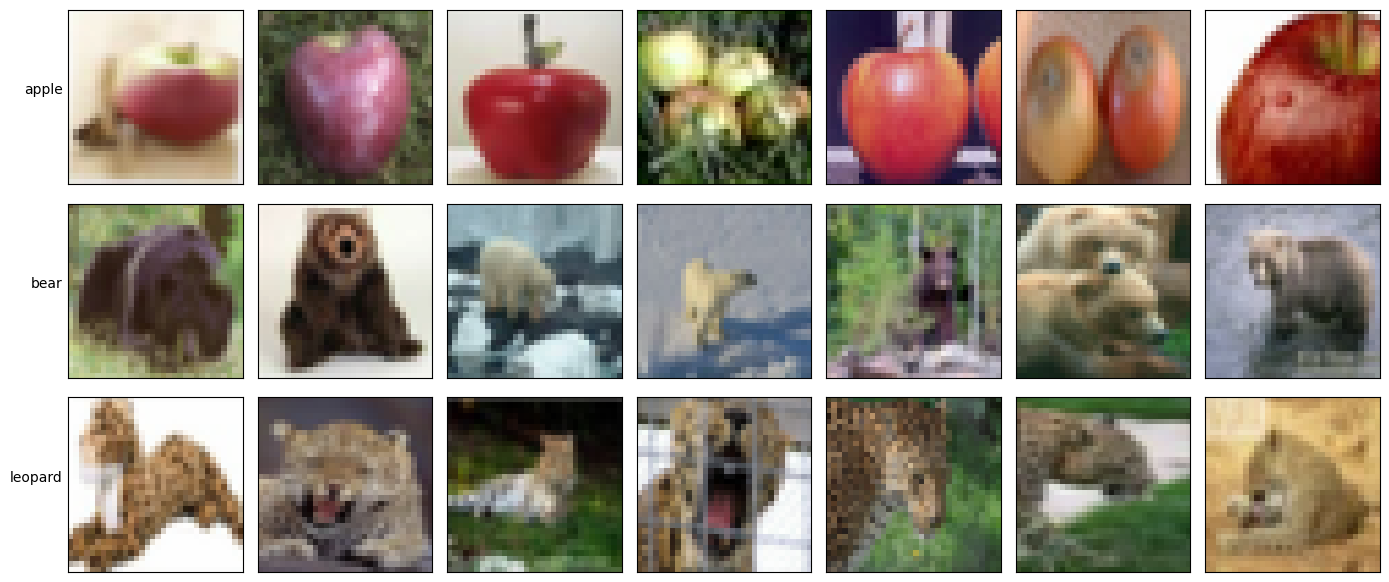

In [41]:
display_classes_examples(train_loader, [0,3,42], 7)

### Learning loop

In [42]:
n_iterations = 5
n_epochs_train = 10
n_epochs_finetune = 10


Learning iteration 1/5:

    [ ] Training on augmented train set...
Epoch 0 started...
Epoch: 1/10 | Time: 159.15s | Train Loss: 4.5236 | Train Acc: 2.03% | Test Loss: 4.4953 | Test Acc: 2.95% | LR: 0.009999
Epoch 1 started...
Epoch: 2/10 | Time: 159.71s | Train Loss: 4.0171 | Train Acc: 8.23% | Test Loss: 3.6907 | Test Acc: 12.44% | LR: 0.009998
Epoch 2 started...
Epoch: 3/10 | Time: 159.57s | Train Loss: 3.5782 | Train Acc: 15.11% | Test Loss: 3.3878 | Test Acc: 17.44% | LR: 0.009994
Epoch 3 started...
Epoch: 4/10 | Time: 152.26s | Train Loss: 3.2656 | Train Acc: 20.21% | Test Loss: 3.1118 | Test Acc: 23.30% | LR: 0.009990
Epoch 4 started...
Epoch: 5/10 | Time: 150.42s | Train Loss: 2.9889 | Train Acc: 25.25% | Test Loss: 2.7411 | Test Acc: 29.56% | LR: 0.009985
Epoch 5 started...
Epoch: 6/10 | Time: 160.84s | Train Loss: 2.7704 | Train Acc: 29.34% | Test Loss: 2.6187 | Test Acc: 32.21% | LR: 0.009978
Epoch 6 started...
Epoch: 7/10 | Time: 159.89s | Train Loss: 2.6068 | Train Acc: 3

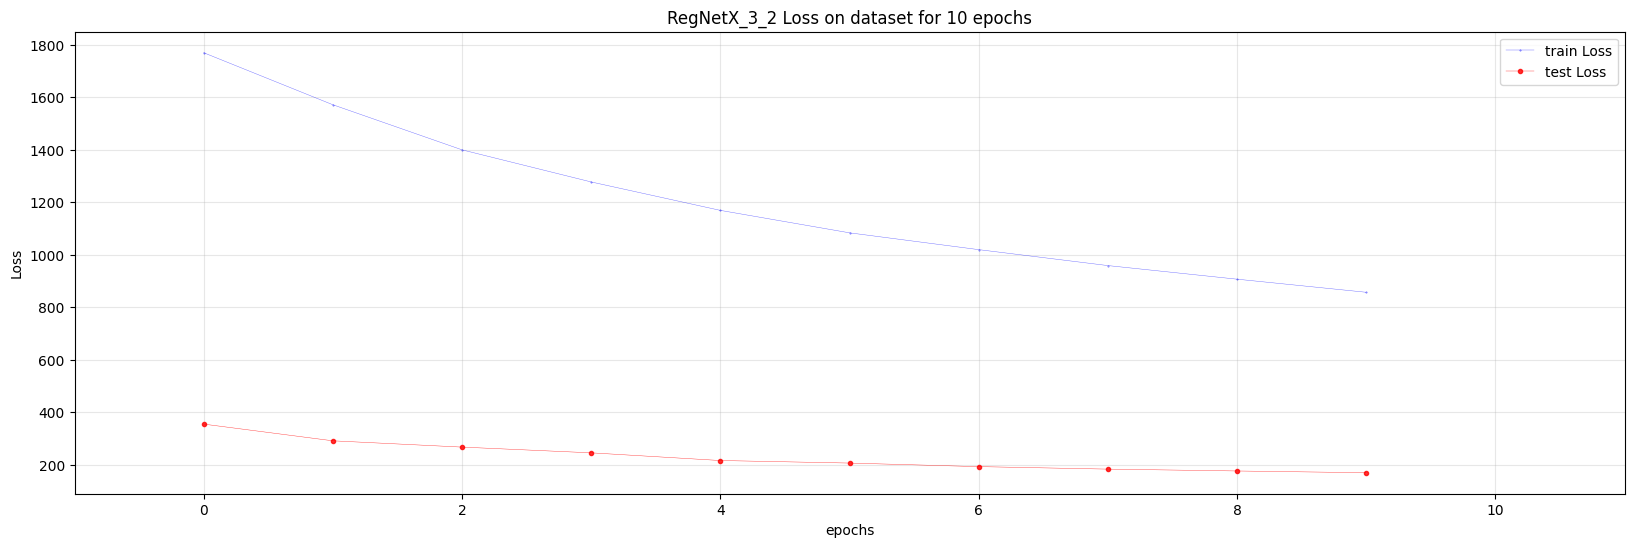

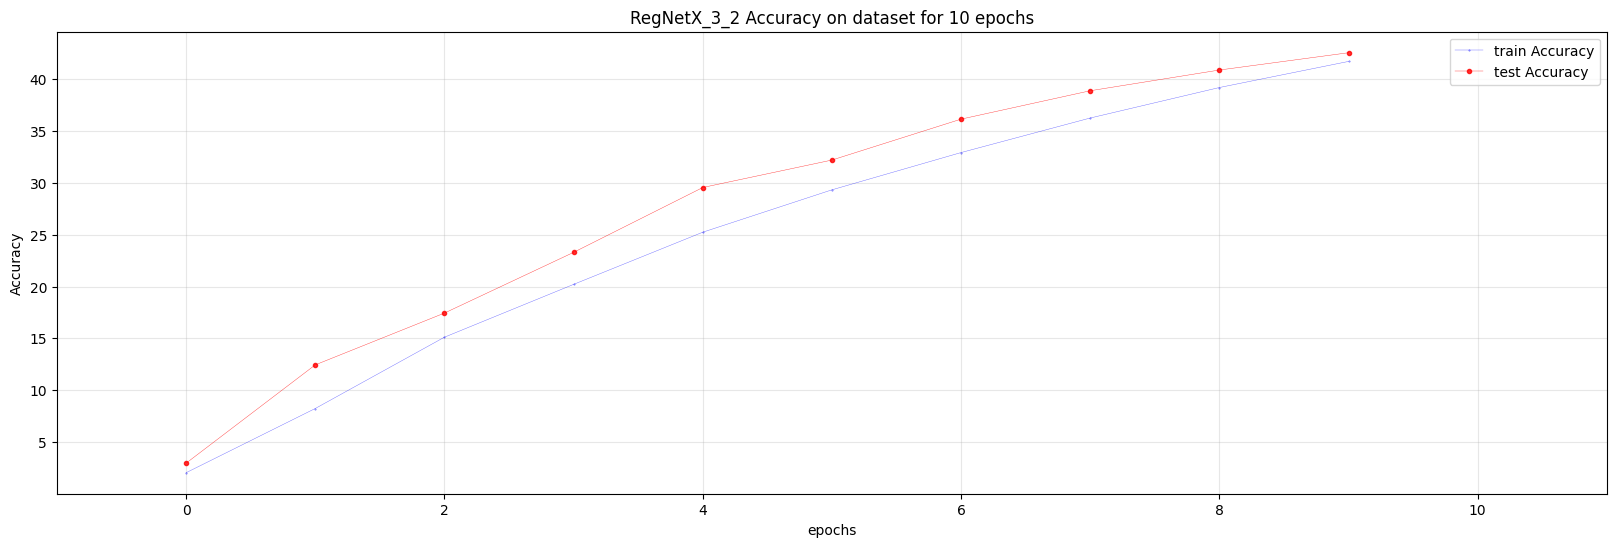

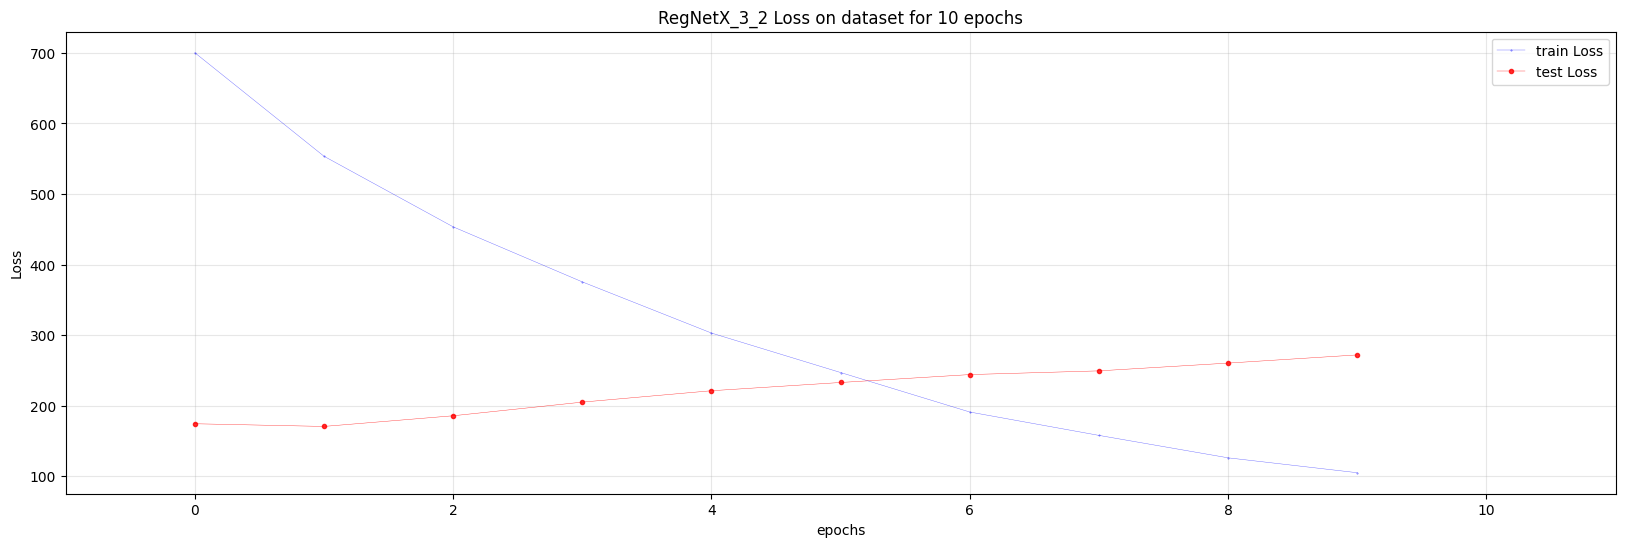

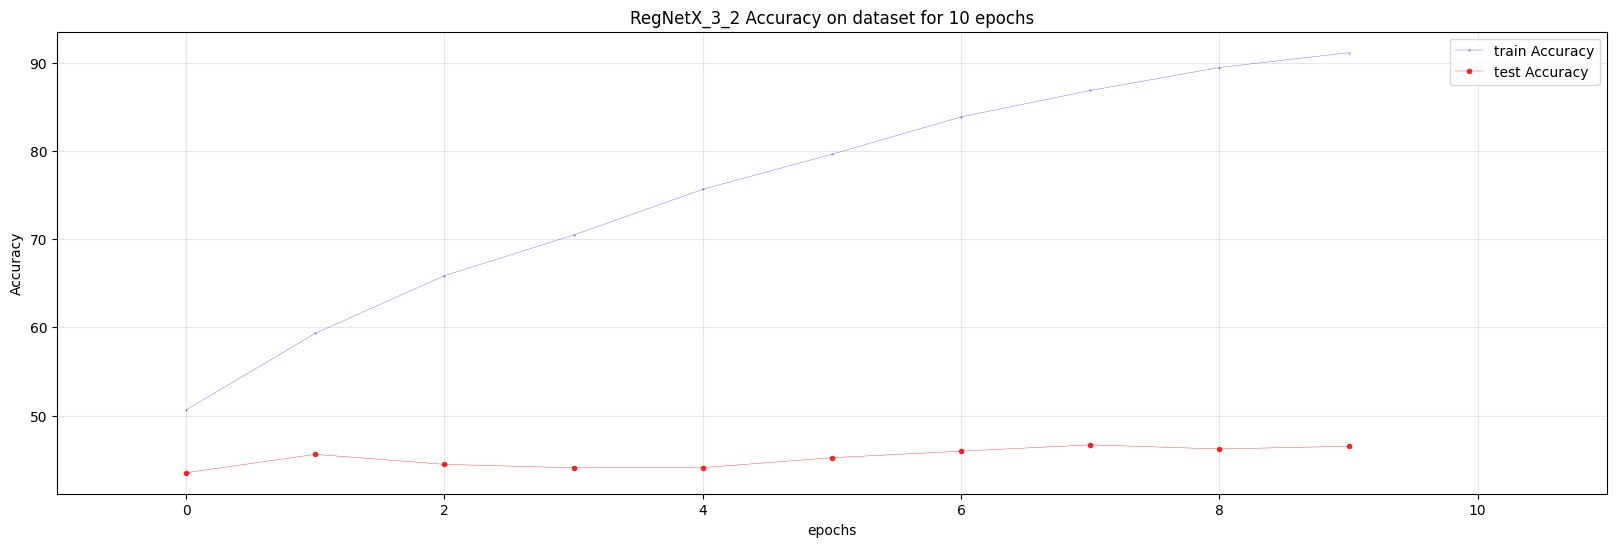

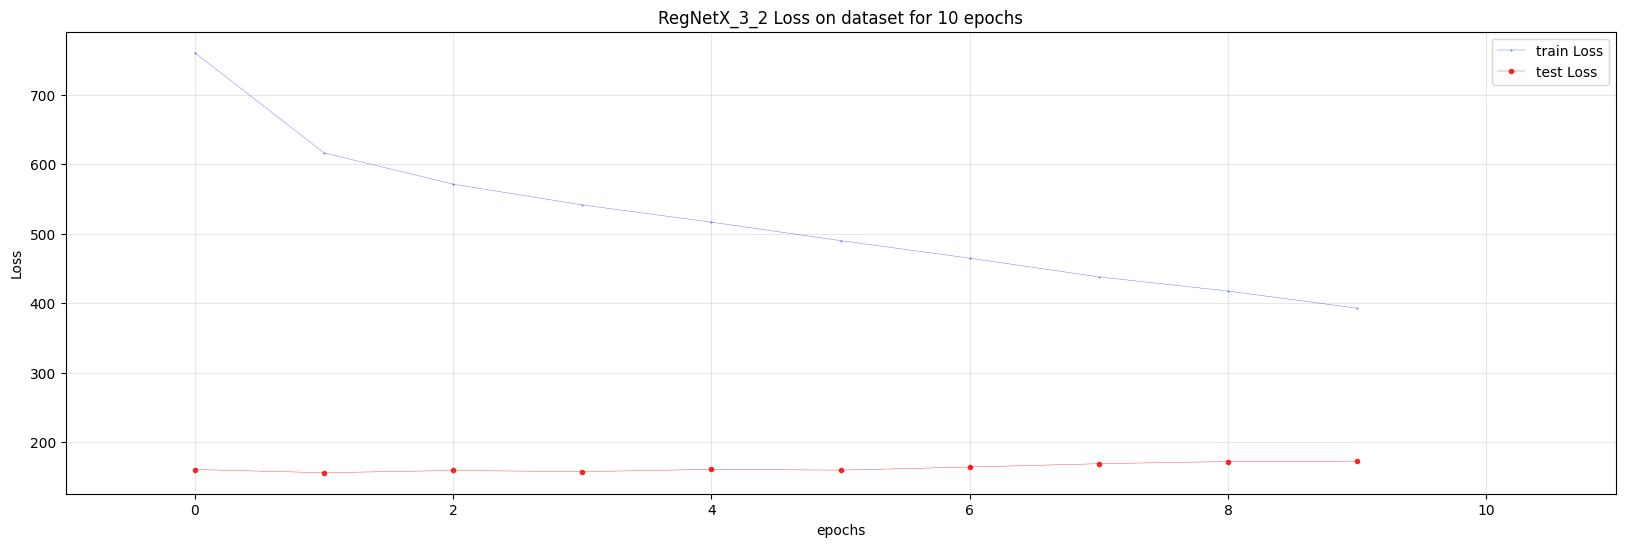

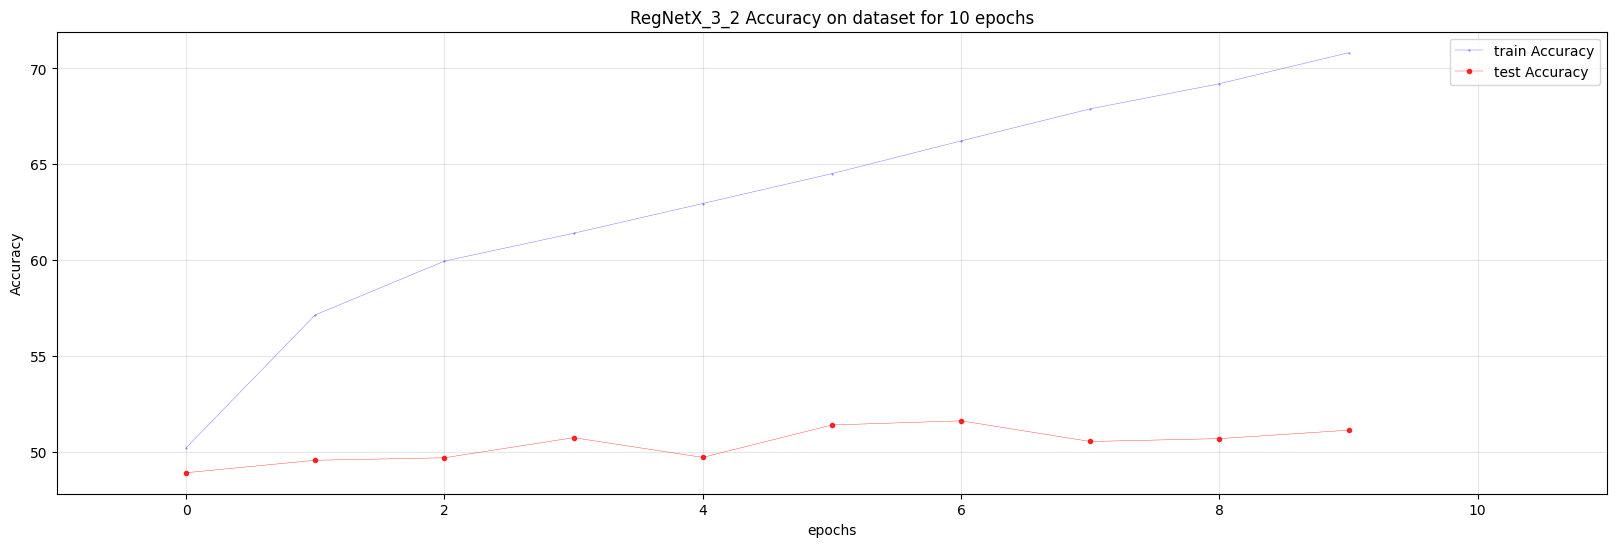

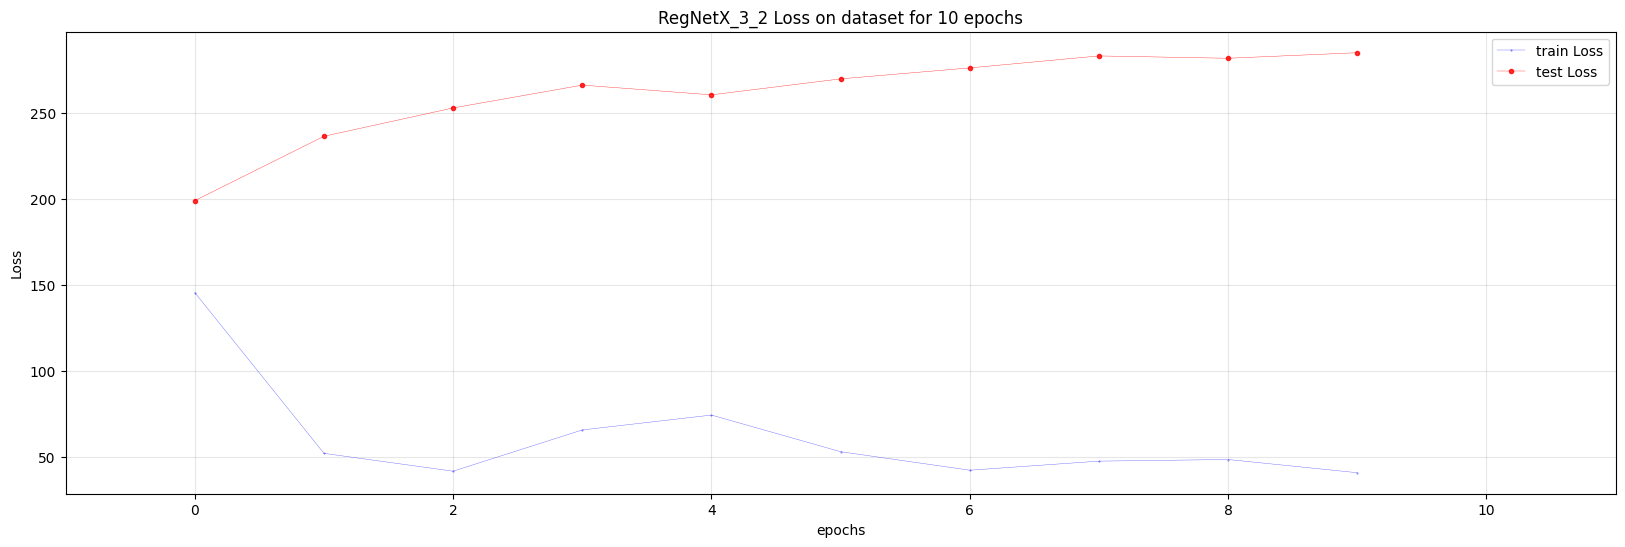

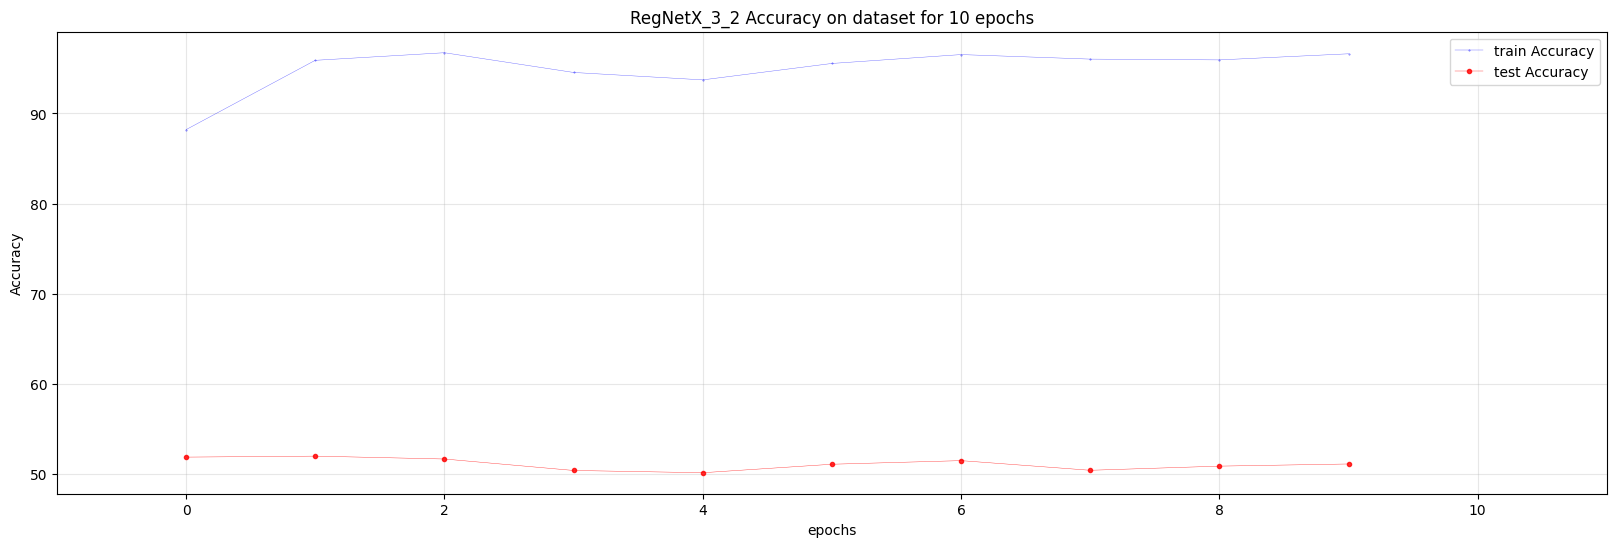

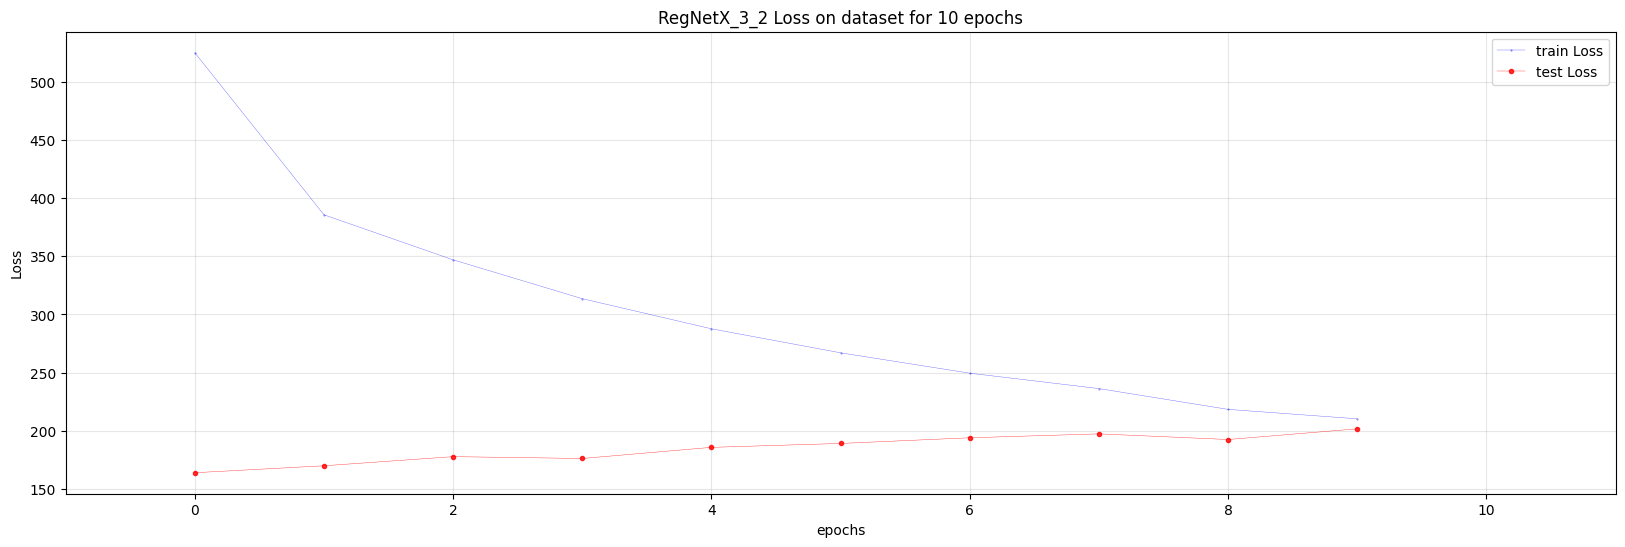

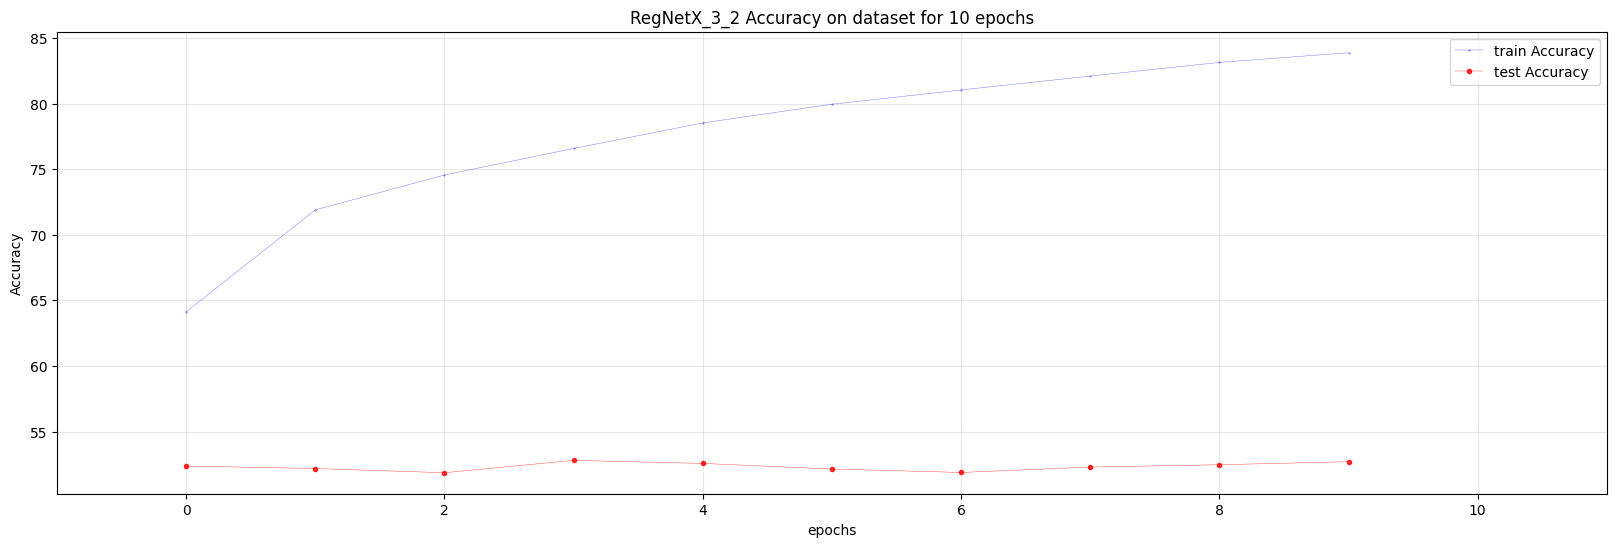

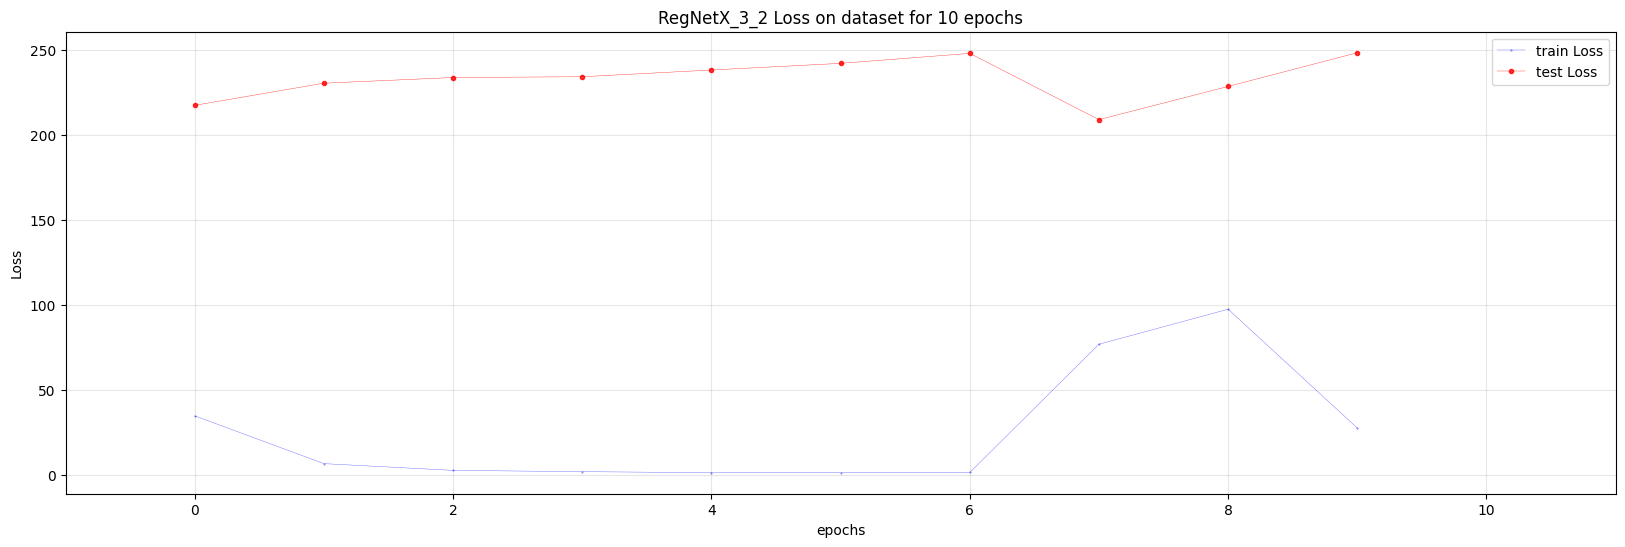

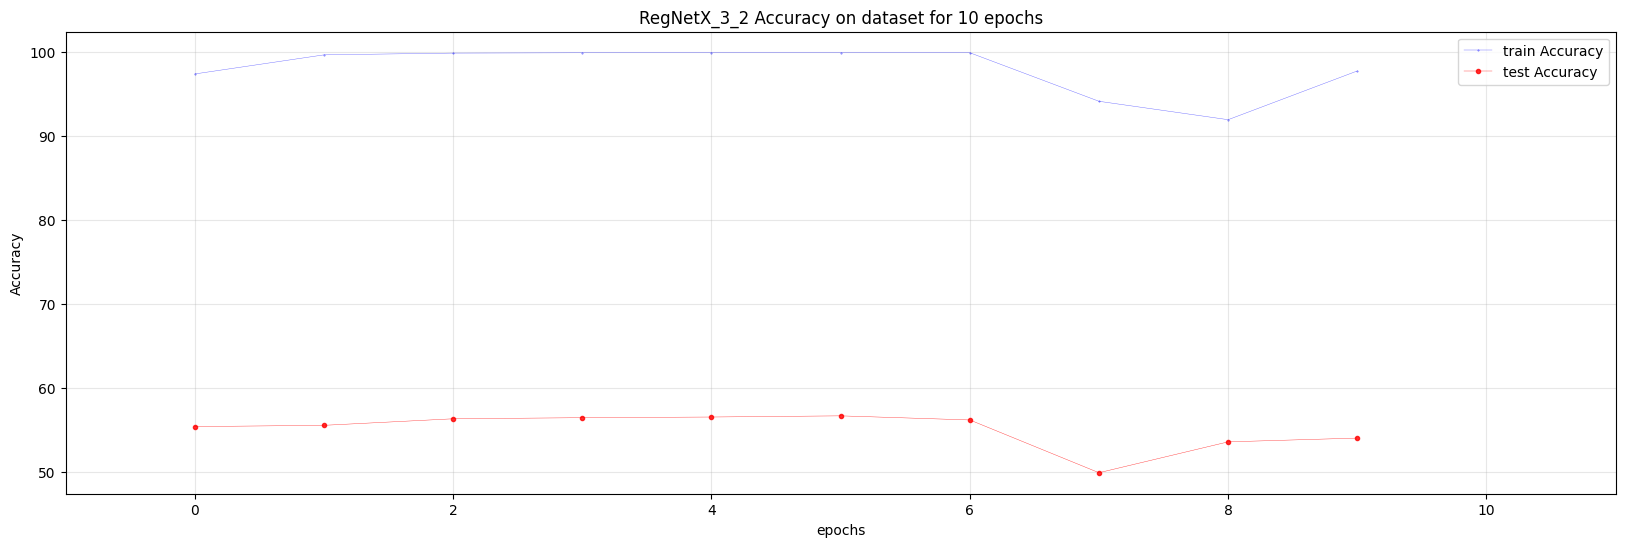

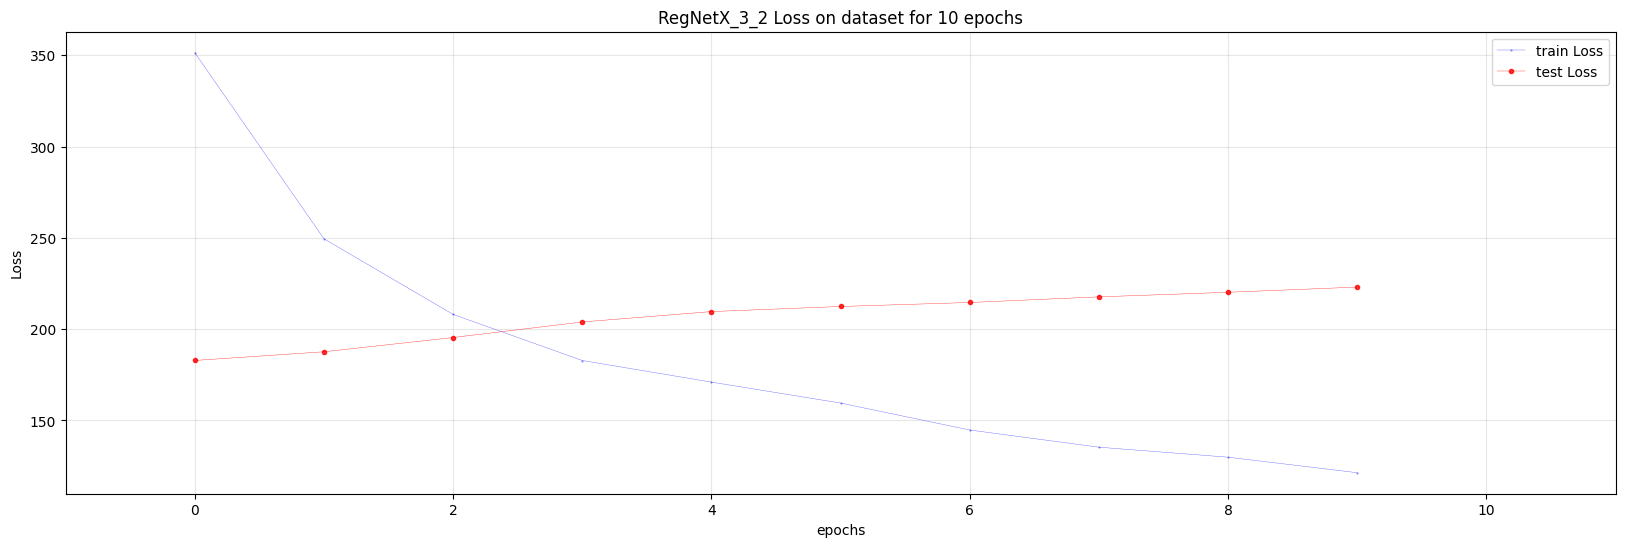

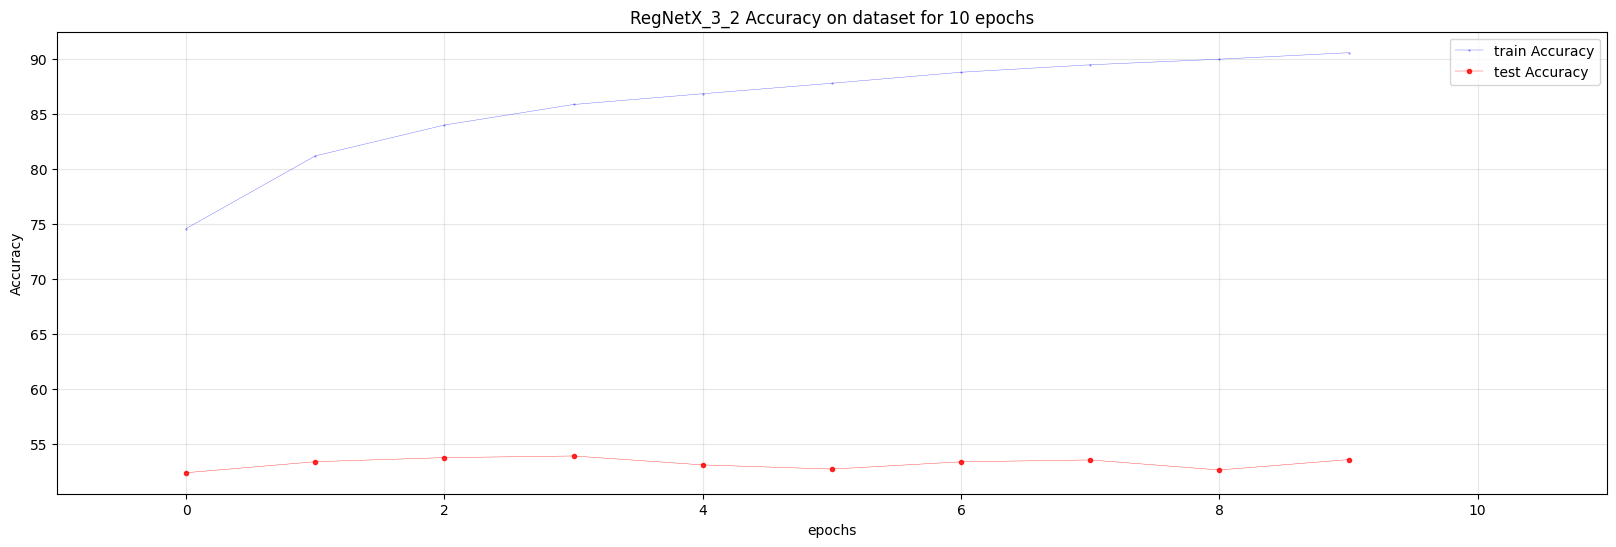

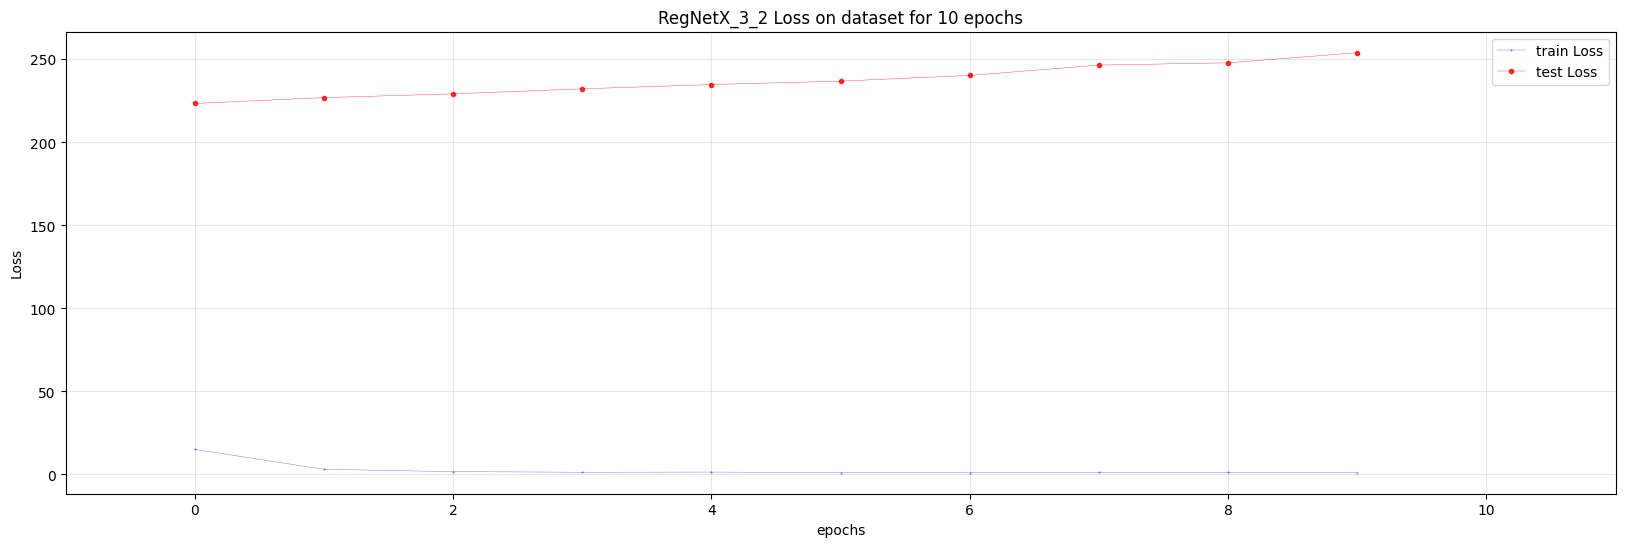

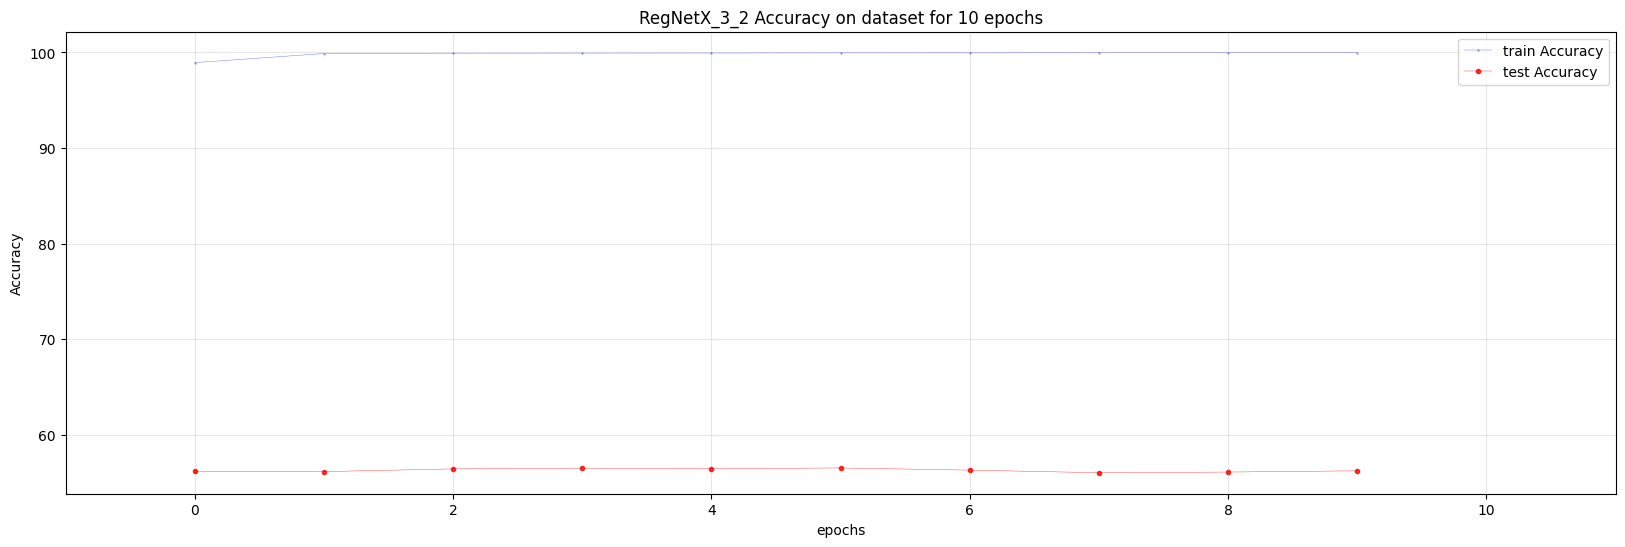

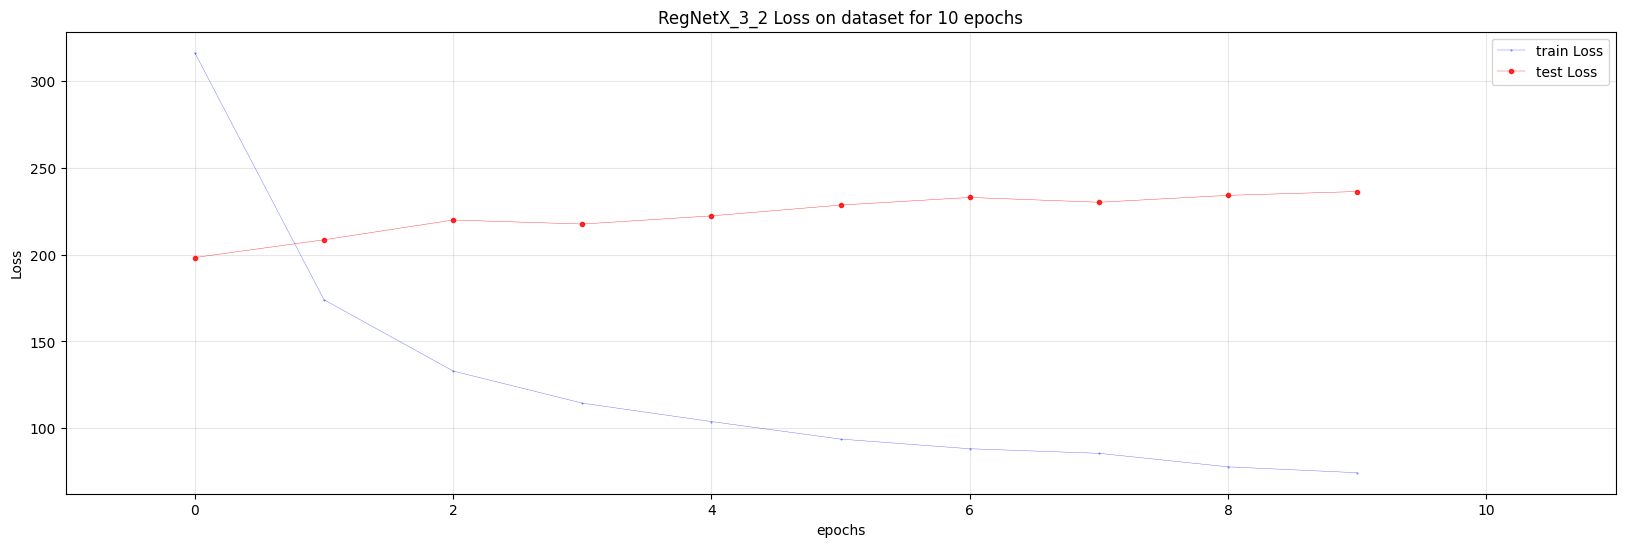

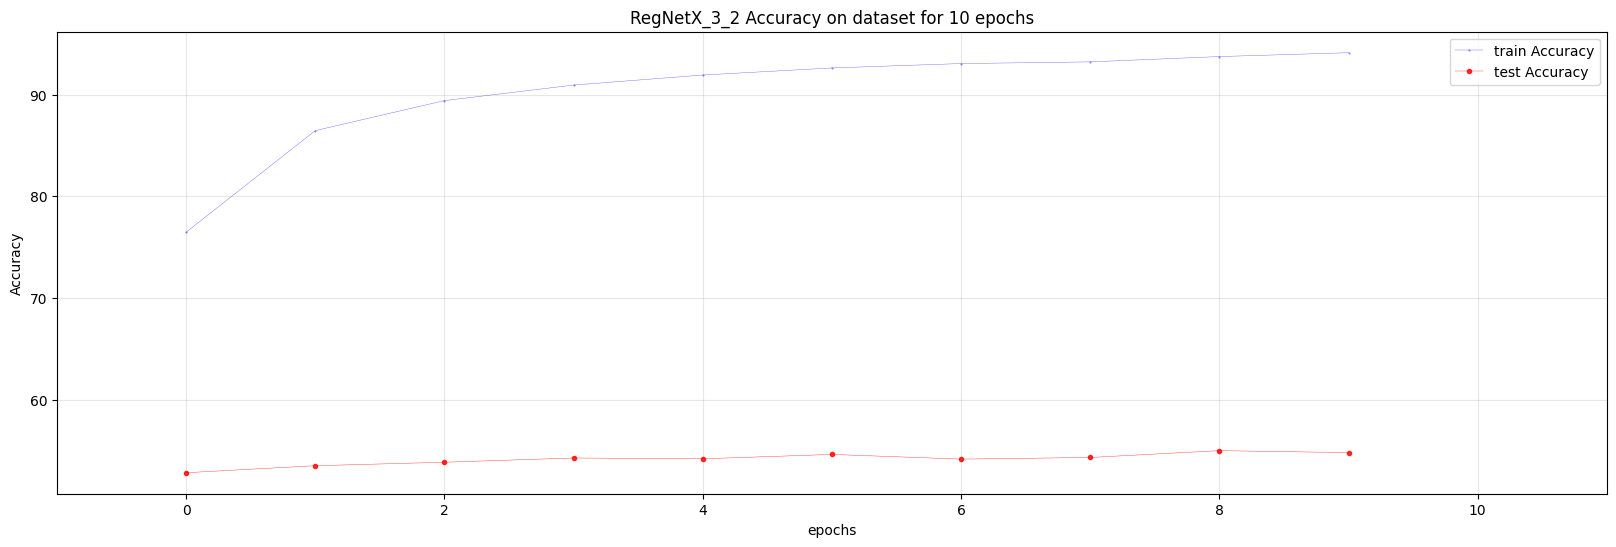

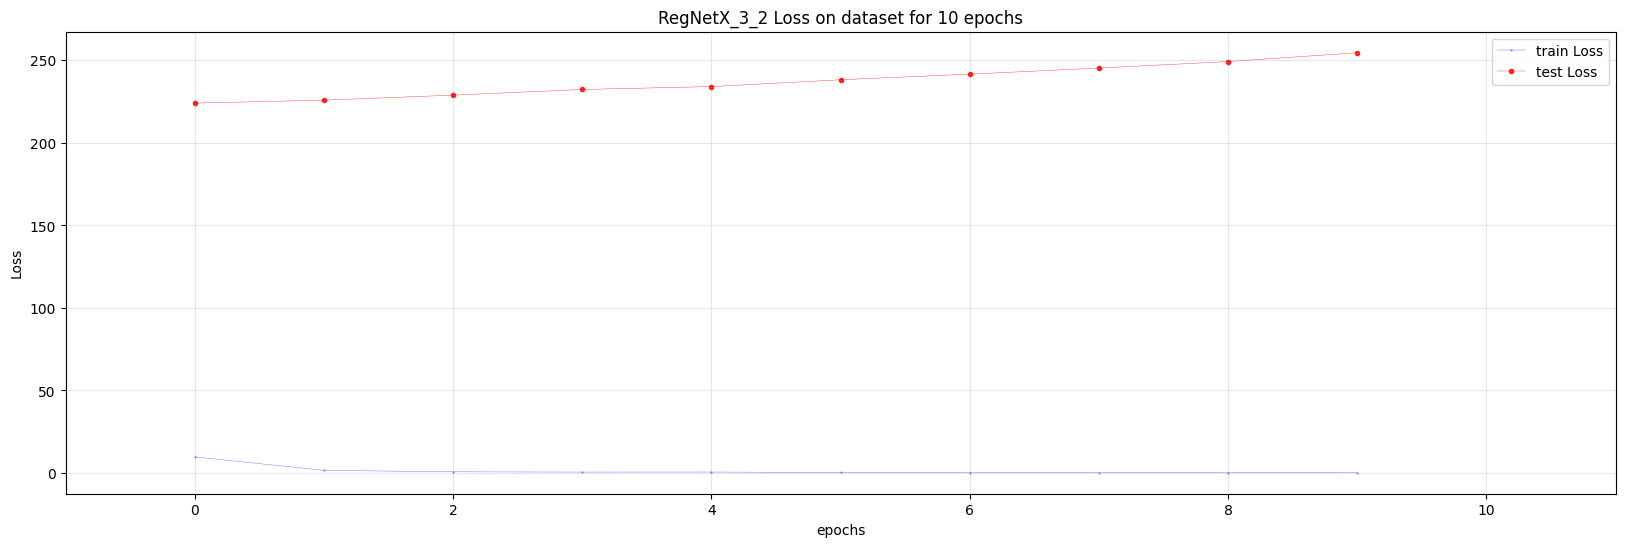

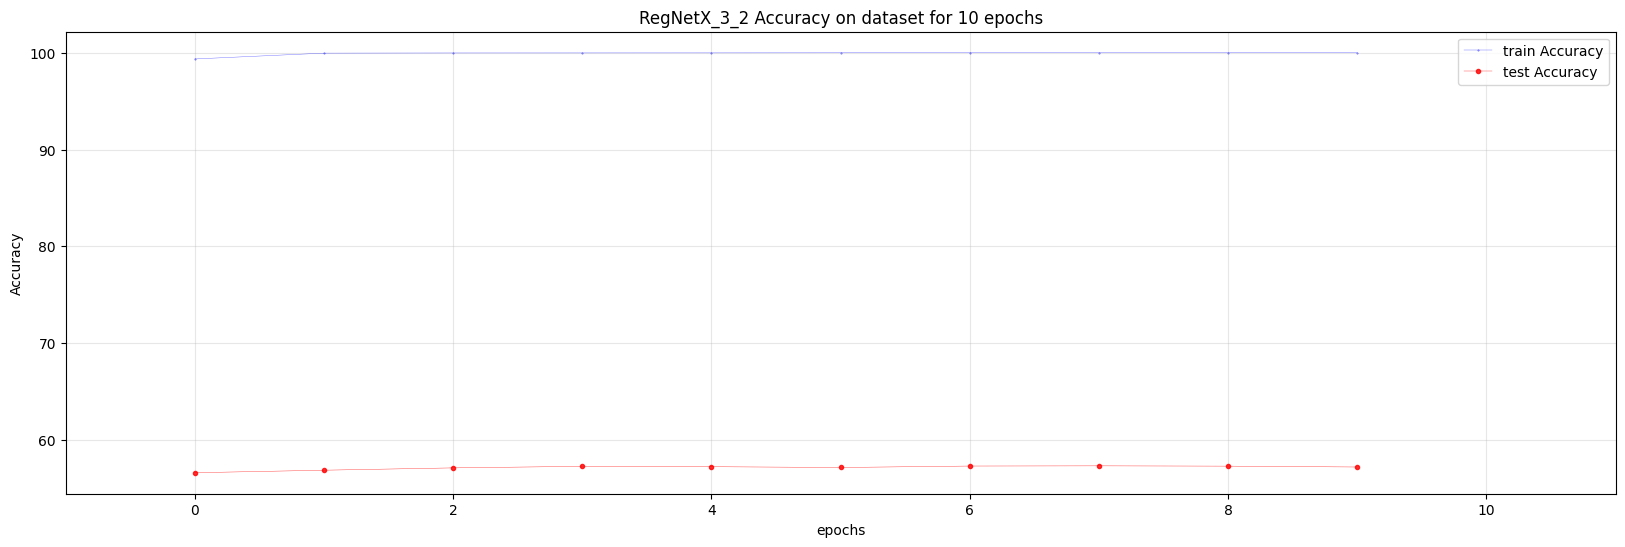

In [43]:
train_losses = []
test_losses = []
train_accs = []
test_accs = [] 

for iteration in range(n_iterations):
    print(f"\nLearning iteration {iteration + 1}/{n_iterations}:\n")
    
    graph_subdir_iteration = os.path.join(graph_dir_iter_aug, f"iteration_{iteration}")
    
    print("    [ ] Training on augmented train set...")
    train_losses_aug, train_accs_aug, test_losses_aug, test_accs_aug = train_n_epochs(
        regnetx_3_2, 
        train_loader_aug, 
        val_loader, 
        optimizer=optimizer,
        criterion=criterion,
        scheduler=scheduler,
        model_name=regnetx_3_2_name,
        device=device, 
        epochs=n_epochs_train,
        checkpoint_dir=checkpoint_dir_iter_aug,
        with_plots=True,
        graph_dir = os.path.join(graph_subdir_iteration, "train")
    )
    print("    [V] Training on augmented train set finished")
    train_losses.append(train_losses_aug)
    test_losses.append(test_losses_aug)
    train_accs.append(train_accs_aug)
    test_accs.append(test_accs_aug)

    print("    [ ] Finetuning on normal train set...")
    train_losses_norm, train_accs_norm, test_losses_norm, test_accs_norm = train_n_epochs(
        regnetx_3_2, 
        train_loader, 
        val_loader, 
        optimizer=optimizer,
        criterion=criterion,
        scheduler=scheduler,
        model_name=regnetx_3_2_name,
        device=device, 
        epochs=n_epochs_finetune,
        checkpoint_dir=checkpoint_dir_iter_aug,
        with_plots=True,
        graph_dir = os.path.join(graph_subdir_iteration, "finetune")
    )
    print("    [V] Finetuning on normal train set finished!")
    train_losses.append(train_losses_norm)
    test_losses.append(test_losses_norm)
    train_accs.append(train_accs_norm)
    test_accs.append(test_accs_norm)
    
    print("Results of training via iterative augmentation are saved in the following folders:")
    print("    graphs:     ", graph_dir)
    print("    checkpoints:", checkpoint_dir)

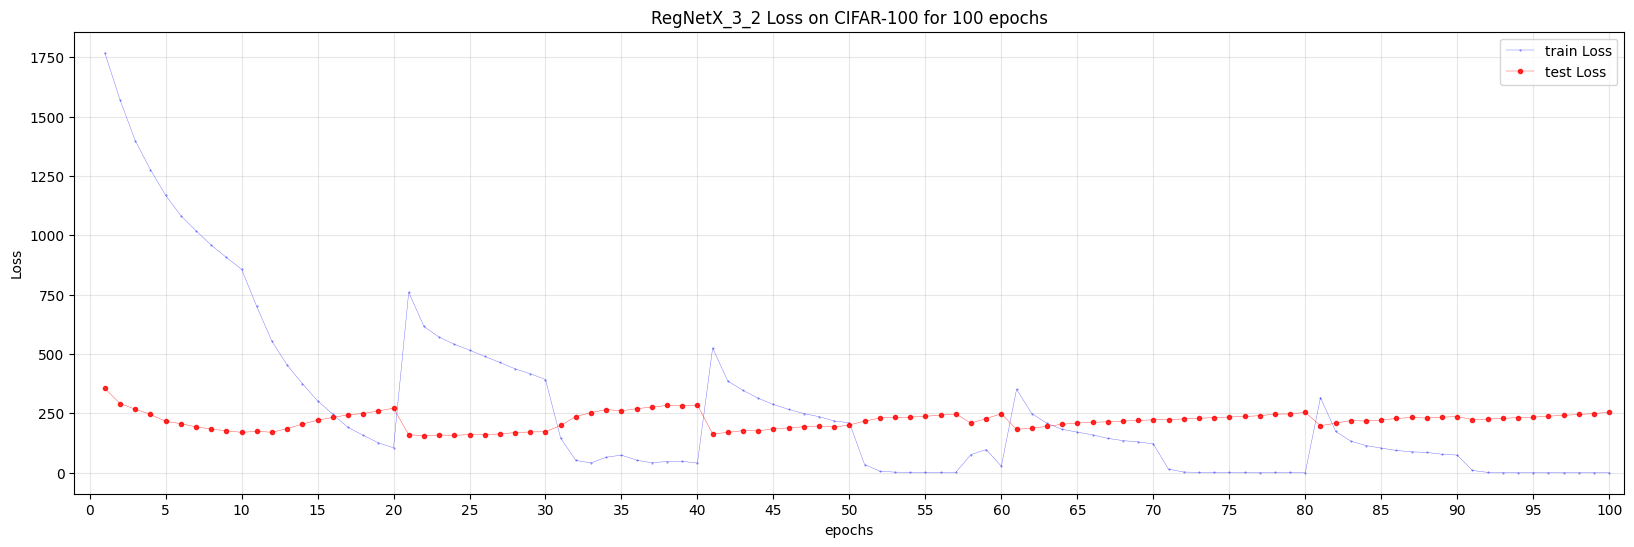

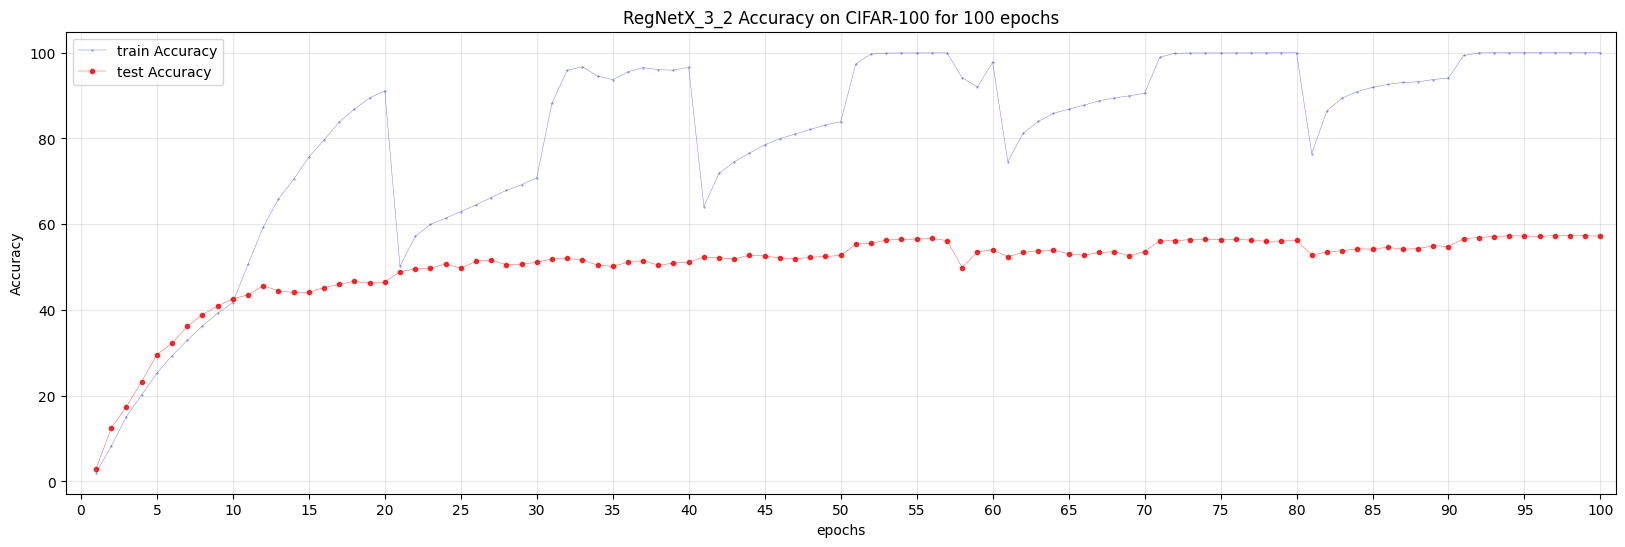

In [87]:
plot_final_losses_accs(
    train_losses, test_losses, 
    train_accs, test_accs,
    regnetx_3_2_name, dataset_name, 
    graph_dir_iter_aug
)

## Iterative layer unfreeze

In [111]:
checkpoint_dir_iter_unfr = os.path.join(checkpoint_dir, "iter_unfreeze")
graph_dir_iter_unfr = os.path.join(graph_dir, "iter_unfreeze")

### Structure & functions preparation

In [ ]:
print("RegNetX_3_2 structure:\n")
print(regnetx_3_2)

In [161]:
for i in range(len(regnetx_3_2.trunk_output)):
    print(f"Length of trunk_output semantic block {i}: {len(regnetx_3_2.trunk_output[i])} blocks")

Length of trunk_output semantic block 0: 2 blocks
Length of trunk_output semantic block 1: 6 blocks
Length of trunk_output semantic block 2: 15 blocks
Length of trunk_output semantic block 3: 2 blocks


In [162]:
semantic_blocks = [
    regnetx_3_2.stem,
    regnetx_3_2.trunk_output[0],
    regnetx_3_2.trunk_output[1],
    regnetx_3_2.trunk_output[2],
    regnetx_3_2.trunk_output[3],
    regnetx_3_2.avgpool,
    regnetx_3_2.fc
] 

In [168]:
def initial_freeze(semantic_blocks: list,
                   block_ids_to_freeze: list[int]):   
    for block_id in block_ids_to_freeze:
        n_params = 0
        for param in semantic_blocks[block_id].parameters():
            n_params += param.requires_grad
            param.requires_grad = False
        print(f"Block {block_id} with {n_params} trainable parameters frozen")

def block_unfreeze(semantic_blocks: list,
                   block_id: int):        
    for param in semantic_blocks[block_id].parameters():
        param.requires_grad = True
    print(f"Block {block_id} unfrozen")

def train_n_epochs_unfreeze(model: torch.nn.Module,
                            semantic_blocks: list,
                            frozen_block_ids: list,
                            train_loader: DataLoader, 
                            test_loader: DataLoader,
                            optimizer,
                            criterion,
                            scheduler,
                            model_name: str = "",
                            dataset_name: str = "dataset",
                            device: torch.device = torch.device("cpu"),
                            epochs: int = 150,
                            checkpoint_dir: str = "checkpoints",
                            with_plots: bool = True,
                            graph_dir: str = "",
                            verbose: bool = True):
    
    os.makedirs(checkpoint_dir, exist_ok=True)
    
    model_name = model_name or model.__class__.__name__
    model.to(device)

    train_losses = []
    test_losses = []
    train_accs = []
    test_accs = []    
    best_acc = 0
    
    block_id_i = len(frozen_block_ids) - 1

    for epoch in range(epochs):
        print(f"Epoch {epoch} started...")
        start_time = time()
        
        if (block_id_i >= 0) and \
           (epoch == (epochs // len(frozen_block_ids) * (len(frozen_block_ids) - 1 - block_id_i))):
            block_unfreeze(semantic_blocks, frozen_block_ids[block_id_i])
            block_id_i -= 1

        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        
        test_loss, test_acc = validate_epoch(model, test_loader, criterion, device)
        test_losses.append(test_loss)
        test_accs.append(test_acc)

        scheduler.step()
        
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "acc": test_acc
        }, os.path.join(checkpoint_dir, f"{model_name}_last_{epochs}epochs.pth"))
        
        if test_acc > best_acc:
            best_acc = test_acc
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "acc": test_acc
            }, os.path.join(checkpoint_dir, f"{model_name}_best_{epochs}epochs.pth"))
        
        if verbose:
            epoch_time = time() - start_time
            print(
                f"Epoch: {epoch+1}/{epochs} | "
                f"Time: {epoch_time:.2f}s | "
                f"Train Loss: {train_loss/len(train_loader):.4f} | "
                f"Train Acc: {train_acc:.2f}% | "
                f"Test Loss: {test_loss/len(test_loader):.4f} | "
                f"Test Acc: {test_acc:.2f}% | "
                f"LR: {scheduler.get_last_lr()[0]:.6f}"
            )

    if with_plots:
        graph_dir = graph_dir or f"graphs_{model_name}_{epochs}epochs"
        os.makedirs(graph_dir, exist_ok=True)
        plot_metric(train_losses, test_losses, epochs, model_name=model_name, dataset_name=dataset_name, metric_name="Loss", graph_dir=graph_dir)
        plot_metric(train_accs, test_accs, epochs, model_name=model_name, dataset_name=dataset_name, metric_name="Accuracy", graph_dir=graph_dir)
    
    print(f"Best accuracy: {best_acc}%")
    
    return train_losses, train_accs, test_losses, test_accs

### Training

In [164]:
n_epochs_frozen = 50
n_epochs_unfreezing = 50

frozen_block_ids = [ i for i in range(len(semantic_blocks) // 2, 
                                      len(semantic_blocks) - 2) ]
# frozen_block_ids = []
frozen_block_ids

[3, 4]

In [165]:
print("[ ] Semantic blocks freeze...")
initial_freeze(semantic_blocks, frozen_block_ids)
print(f"[V] Semantic blocks {frozen_block_ids} frozen")

[ ] Semantic blocks freeze...
Block 3 with 138 trainable parameters frozen
Block 4 with 21 trainable parameters frozen
[V] Semantic blocks [3, 4] frozen


[ ] Training model with frozen deepest layers...
Epoch 0 started...
Epoch: 1/50 | Time: 142.85s | Train Loss: 4.8098 | Train Acc: 2.29% | Test Loss: 4.7714 | Test Acc: 1.78% | LR: 0.009999
Epoch 1 started...
Epoch: 2/50 | Time: 136.27s | Train Loss: 4.5367 | Train Acc: 2.99% | Test Loss: 4.4511 | Test Acc: 4.18% | LR: 0.009998
Epoch 2 started...
Epoch: 3/50 | Time: 130.23s | Train Loss: 4.5815 | Train Acc: 2.86% | Test Loss: 4.6365 | Test Acc: 1.39% | LR: 0.009994
Epoch 3 started...
Epoch: 4/50 | Time: 129.69s | Train Loss: 4.5271 | Train Acc: 2.98% | Test Loss: 4.9348 | Test Acc: 2.62% | LR: 0.009990
Epoch 4 started...
Epoch: 5/50 | Time: 128.84s | Train Loss: 4.5814 | Train Acc: 2.89% | Test Loss: 5.1481 | Test Acc: 2.67% | LR: 0.009985
Epoch 5 started...
Epoch: 6/50 | Time: 128.97s | Train Loss: 4.5218 | Train Acc: 3.75% | Test Loss: 5.2478 | Test Acc: 4.60% | LR: 0.009978
Epoch 6 started...
Epoch: 7/50 | Time: 129.05s | Train Loss: 4.3286 | Train Acc: 5.15% | Test Loss: 4.6186 | Te

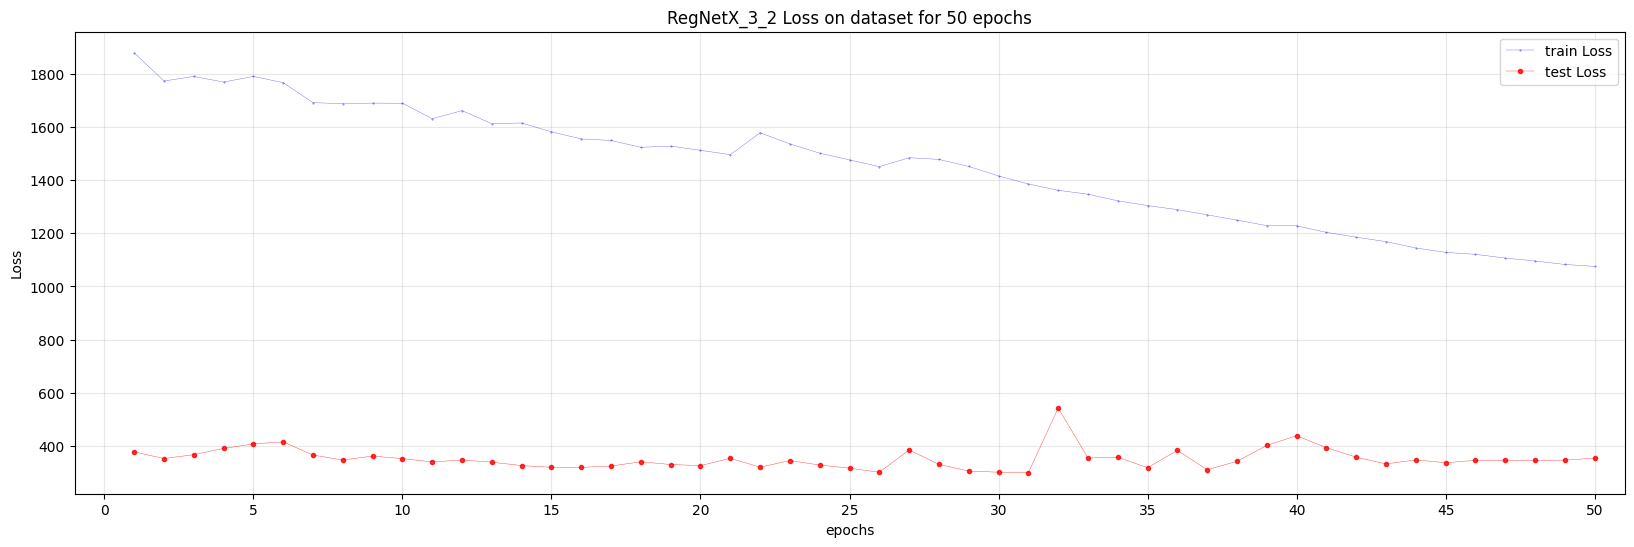

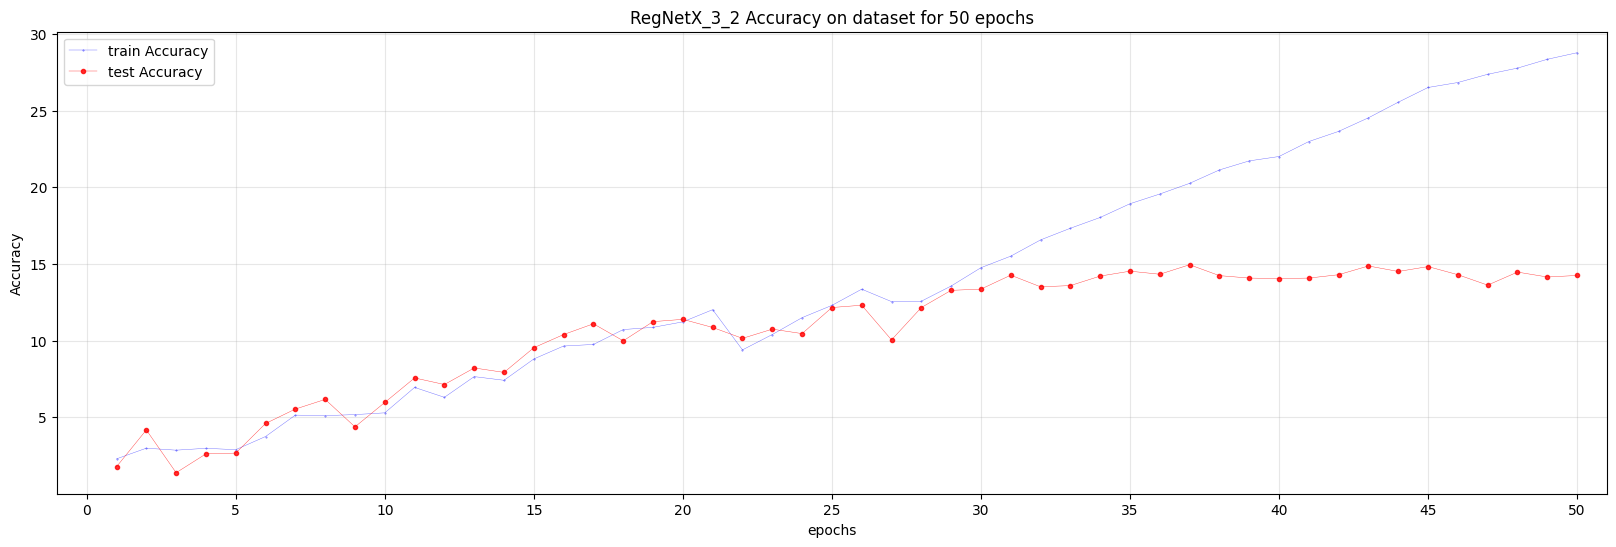

In [166]:
print("[ ] Training model with frozen deepest layers...")
train_losses, train_accs, test_losses, test_accs = train_n_epochs(
    regnetx_3_2, 
    train_loader, 
    val_loader, 
    optimizer=optimizer,
    criterion=criterion,
    scheduler=scheduler,
    model_name=regnetx_3_2_name,
    device=device, 
    epochs=n_epochs_frozen,
    checkpoint_dir=checkpoint_dir_iter_unfr,
    with_plots=True,
    graph_dir = os.path.join(graph_dir_iter_unfr, "frozen")
)
print("[V] Model with frozen deepest layers trained")

[ ] Training model with iterative unfreezing...
Epoch 0 started...
Block 4 unfrozen
Epoch: 1/50 | Time: 136.11s | Train Loss: 6.8117 | Train Acc: 8.58% | Test Loss: 45.2467 | Test Acc: 12.14% | LR: 0.008480
Epoch 1 started...
Epoch: 2/50 | Time: 138.74s | Train Loss: 4.7734 | Train Acc: 14.09% | Test Loss: 362.2506 | Test Acc: 13.78% | LR: 0.008423
Epoch 2 started...
Epoch: 3/50 | Time: 134.66s | Train Loss: 4.4148 | Train Acc: 16.40% | Test Loss: 5.3365 | Test Acc: 17.78% | LR: 0.008365
Epoch 3 started...
Epoch: 4/50 | Time: 135.14s | Train Loss: 4.2702 | Train Acc: 18.42% | Test Loss: 7.7970 | Test Acc: 19.30% | LR: 0.008307
Epoch 4 started...
Epoch: 5/50 | Time: 135.65s | Train Loss: 3.9044 | Train Acc: 20.69% | Test Loss: 7.0035 | Test Acc: 21.09% | LR: 0.008247
Epoch 5 started...
Epoch: 6/50 | Time: 135.32s | Train Loss: 3.8029 | Train Acc: 22.13% | Test Loss: 5.9932 | Test Acc: 21.81% | LR: 0.008187
Epoch 6 started...
Epoch: 7/50 | Time: 137.78s | Train Loss: 3.5627 | Train Acc: 

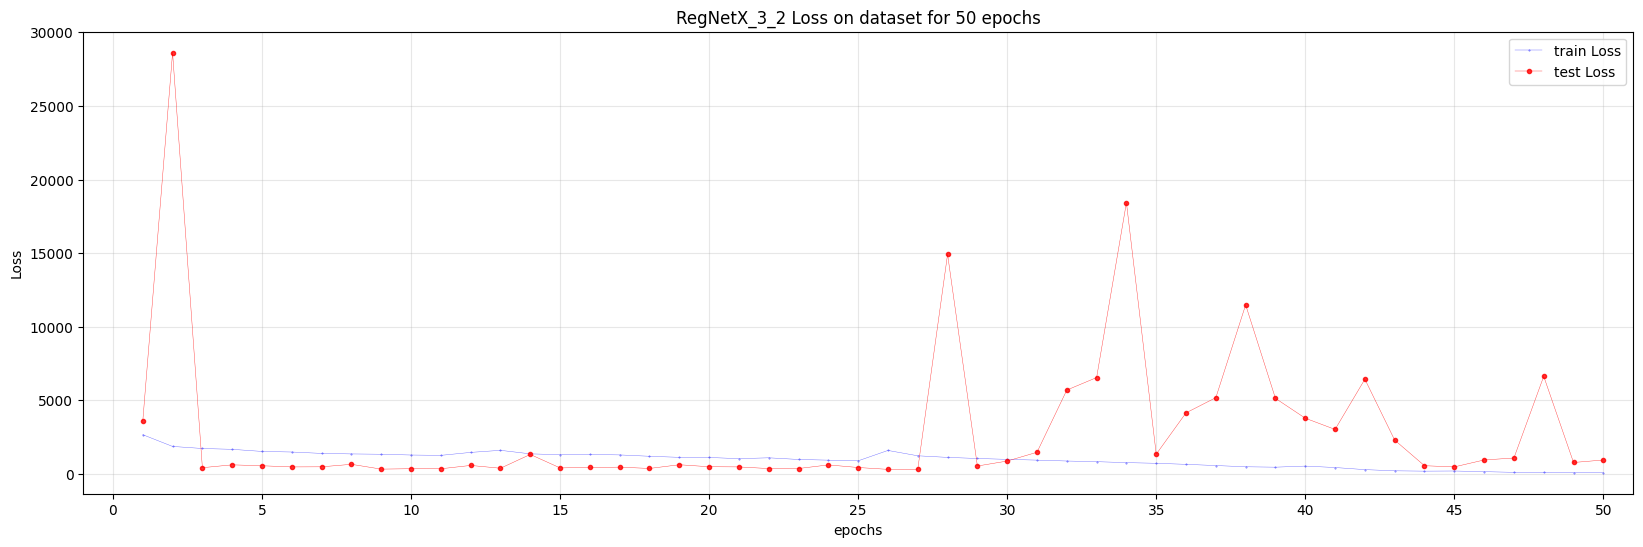

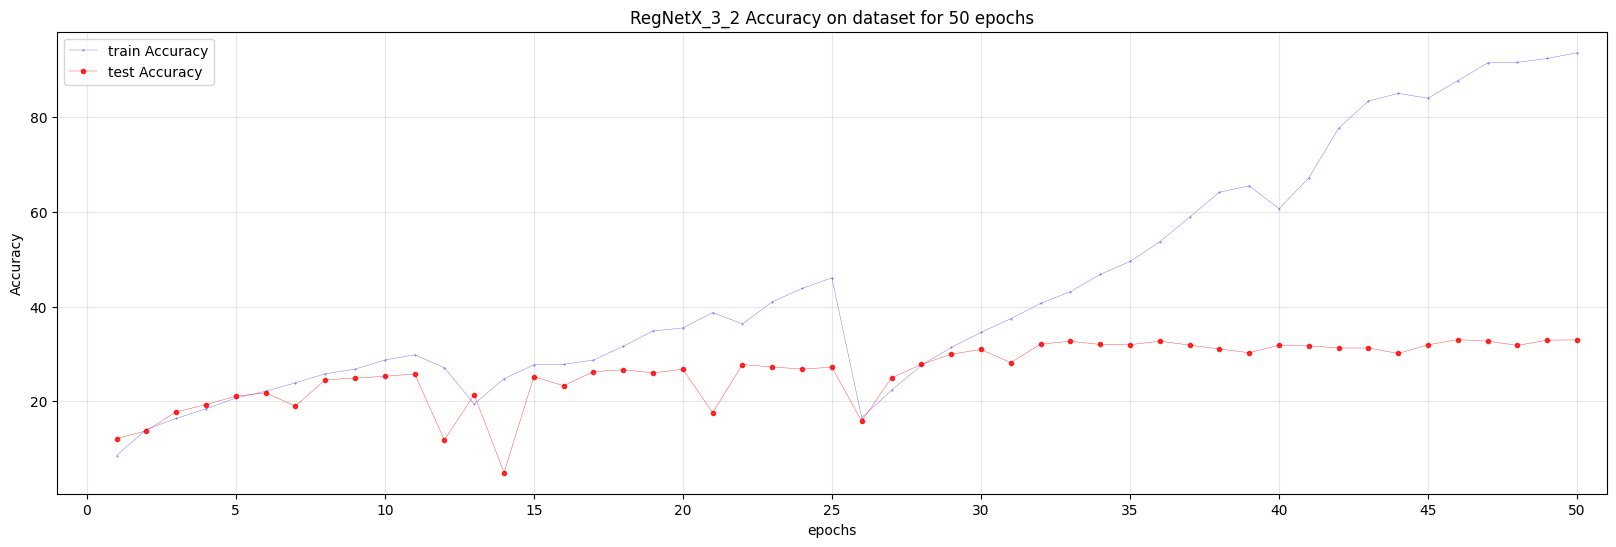

In [ ]:
print("[ ] Training model with iterative unfreezing...")
train_losses_unfr, train_accs_unfr, test_losses_unfr, test_accs_unfr = train_n_epochs_unfreeze(
        regnetx_3_2, 
        semantic_blocks,
        frozen_block_ids,
        train_loader, 
        val_loader, 
        optimizer,
        criterion,
        scheduler,
        model_name=regnetx_3_2_name,
        device=device, 
        epochs=n_epochs_unfreezing,
        checkpoint_dir=checkpoint_dir_iter_unfr,
        with_plots=True,
        graph_dir = os.path.join(graph_dir_iter_unfr, "unfrozen")
    )
print("[V] Model with unfrozen deepest layers trained!")
train_losses += train_losses_unfr
test_losses += test_losses_unfr
train_accs += train_accs_unfr
test_accs += test_accs_unfr
    
print("\nResults of training via iterative augmentation are saved in the following folders:")
print("    graphs:     ", graph_dir_iter_unfr)
print("    checkpoints:", checkpoint_dir_iter_unfr)

In [ ]:
plot_final_losses_accs(
    train_losses, test_losses, 
    train_accs, test_accs, 
    regnetx_3_2_name, dataset_name, 
    graph_dir_iter_unfr
)

## Pseudolabelling

In [14]:
checkpoint_dir_pseudolbl = os.path.join(checkpoint_dir, "pseudolabel")
graph_dir_pseudolbl = os.path.join(graph_dir, "pseudolabel")

### Dataloader creation

In [78]:
class PseudolabelDataset(Dataset):
    def __init__(self, data, targets):
        self.data = data
        self.targets = targets.long()
        
    def __getitem__(self, index):
        target = self.targets[index]
        if not isinstance(target, torch.Tensor):
            target = torch.tensor(target, dtype=torch.long)
        return self.data[index], target
        
    def __len__(self):
        return len(self.data)
    
    
def pseudo_collate_fn(batch):
    data_list = []
    target_list = []
    
    for data, target in batch:
        data_list.append(data)
        
        if not isinstance(target, torch.Tensor):
            target = torch.tensor(target, dtype=torch.long)
        target_list.append(target)
    
    if data_list:
        data_batch = torch.stack(data_list, dim=0)
        target_batch = torch.stack(target_list, dim=0)
        return data_batch, target_batch
    else:
        return None


def generate_pseudo_labels(model: torch.nn.Module, 
                           orig_loader: DataLoader, 
                           device: torch.device = torch.device("cpu"),
                           confidence_threshold: float = 0.99):    
    model.eval()
    pseudo_inputs = []
    pseudo_targets = []
    
    with torch.no_grad():
        for inputs, targets in orig_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)

            probabilities = torch.softmax(outputs, dim=1)
            pred_probs, predictions = torch.max(probabilities, dim=1)
            
            confidence_mask = pred_probs >= confidence_threshold
            confidence_inputs = inputs[confidence_mask]
            confidence_predictions = predictions[confidence_mask]
            
            if len(confidence_inputs):
                pseudo_inputs.append(confidence_inputs.cpu())
                pseudo_targets.append(confidence_predictions.cpu())
    
    if pseudo_inputs:
        pseudo_inputs = torch.cat(pseudo_inputs)
        pseudo_targets = torch.cat(pseudo_targets)
        return PseudolabelDataset(pseudo_inputs, pseudo_targets)
    else:
        return []


def make_pseudo_loader(orig_loader: DataLoader,
                       pseudo_dataset: Dataset):
        return DataLoader(
            ConcatDataset([orig_loader.dataset, pseudo_dataset]),
            batch_size=orig_loader.batch_size,
            shuffle=True,
            num_workers=0,
            pin_memory=orig_loader.pin_memory,
            collate_fn = pseudo_collate_fn
        )

### Learning loop

Here the fine-tuned model from **Preparation. Fine-tuning RegNetX_3_2 on CIFAR-100** section is used.

In [17]:
n_epochs_finetune = 20
confidence_threshold = 1

In [79]:
train_losses = []
train_accs = []
test_losses = []
test_accs = []
    
print(f"    [ ] Generating pseudolabels on test set with confidence threshold {confidence_threshold}...")
pseudo_dataset = generate_pseudo_labels(
    regnetx_3_2, 
    val_loader, 
    device, 
    confidence_threshold=confidence_threshold
)
print(f"    [V] Pseudolabels for train set with confidence threshold {confidence_threshold} created")
if not pseudo_dataset:
    print(f"""There are no examples with confidence threshold above {confidence_threshold}. 
          Consider decreasing the threshold.""")
       
print(f"    [ ] Adding examples with pseudolabels to train set...")  
train_pseudo_loader = make_pseudo_loader(val_loader, pseudo_dataset)
print(f"    [V] Added {len(pseudo_dataset)} examples with pseudolabels to train set")  

    [ ] Generating pseudolabels on test set with confidence threshold 1...
    [V] Pseudolabels for train set with confidence threshold 1 created
    [ ] Adding examples with pseudolabels to train set...
    [V] Added 1010 examples with pseudolabels to train set


    [ ] Fine-tuning on dataset with pseudolabels...
Epoch 0 started...
Epoch: 1/20 | Time: 43.06s | Train Loss: 3.0267 | Train Acc: 60.64% | Test Loss: 3.2752 | Test Acc: 56.97% | LR: 0.009998
Epoch 1 started...
Epoch: 2/20 | Time: 42.41s | Train Loss: 3.0351 | Train Acc: 60.32% | Test Loss: 3.2705 | Test Acc: 56.85% | LR: 0.009994
Epoch 2 started...
Epoch: 3/20 | Time: 38.96s | Train Loss: 2.9618 | Train Acc: 60.30% | Test Loss: 3.3173 | Test Acc: 56.92% | LR: 0.009990
Epoch 3 started...
Epoch: 4/20 | Time: 38.95s | Train Loss: 2.9679 | Train Acc: 60.63% | Test Loss: 3.2377 | Test Acc: 56.84% | LR: 0.009985
Epoch 4 started...
Epoch: 5/20 | Time: 38.97s | Train Loss: 3.0236 | Train Acc: 60.70% | Test Loss: 3.4601 | Test Acc: 55.84% | LR: 0.009978
Epoch 5 started...
Epoch: 6/20 | Time: 39.07s | Train Loss: 2.9377 | Train Acc: 60.35% | Test Loss: 3.2473 | Test Acc: 57.07% | LR: 0.009970
Epoch 6 started...
Epoch: 7/20 | Time: 39.14s | Train Loss: 2.9323 | Train Acc: 60.43% | Test Loss: 3.

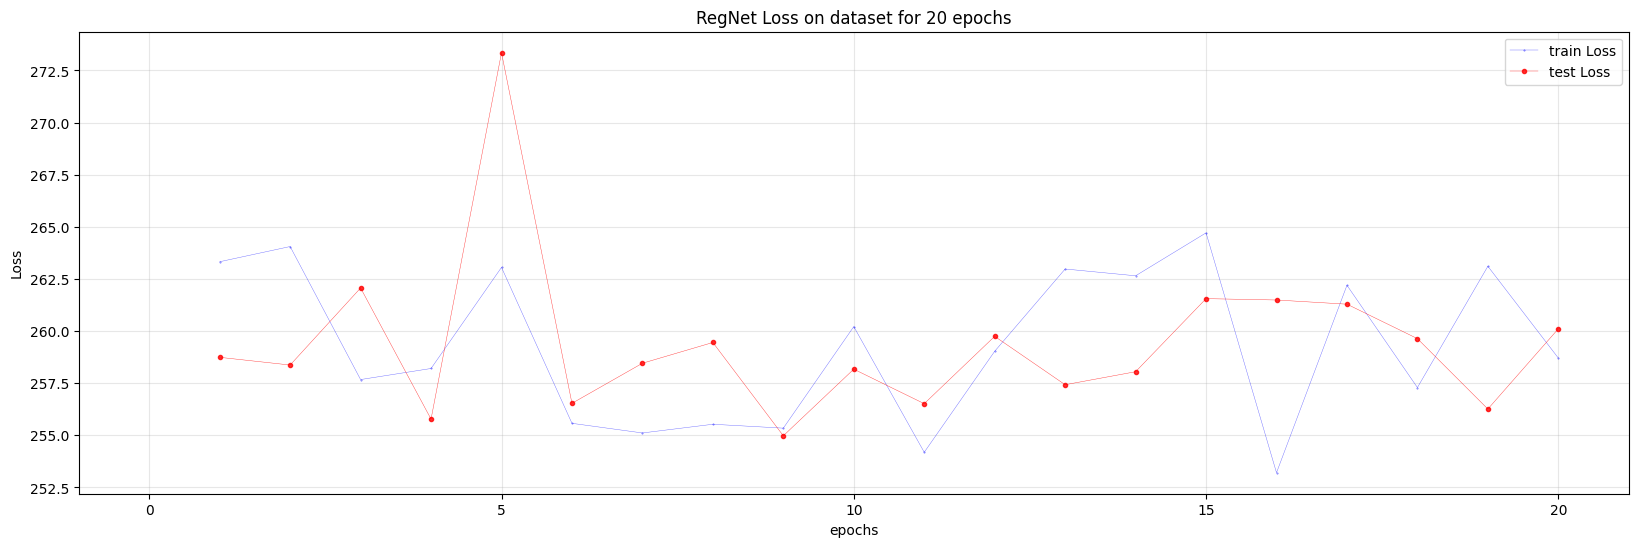

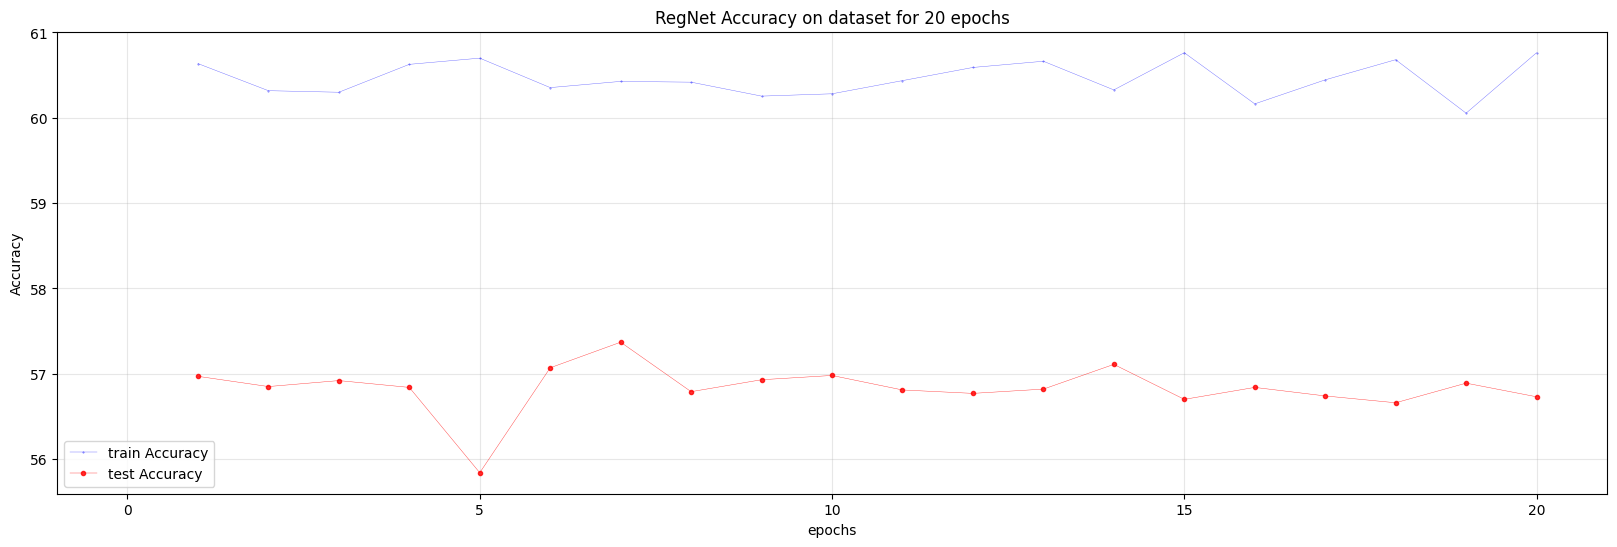

In [80]:
print("    [ ] Fine-tuning on dataset with pseudolabels...")
train_losses, train_accs, test_losses, test_accs = train_n_epochs(
    regnetx_3_2, 
    train_pseudo_loader, 
    val_loader, 
    optimizer=optimizer,
    criterion=criterion,
    scheduler=scheduler,
    device=device, 
    epochs=n_epochs_finetune,
    checkpoint_dir=checkpoint_dir_pseudolbl,
    with_plots=True,
    graph_dir = graph_dir_pseudolbl
)
print("    [V] Fine-tuning on dataset with pseudolabels finished!")

### Pseudolabeling quality estimation

In [84]:
def validate_pseudolabels(model: torch.nn.Module, 
                          test_loader: DataLoader, 
                          device: torch.device = torch.device("cpu"),
                          confidence_threshold: float = 0.9): 
    model.eval()
    total_samples = 0
    correct_pseudo = 0
    high_confidence_count = 0

    pseudo_acc = 0
    pseudo_coverage = 0
    
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            probabilities = torch.softmax(outputs, dim=1)
            max_probs, predictions = torch.max(probabilities, dim=1)
            
            confidence_mask = max_probs >= confidence_threshold
            high_confidence_count += confidence_mask.sum().item()
            
            correct_pseudo += (predictions[confidence_mask] == targets[confidence_mask]).sum().item()
            total_samples += confidence_mask.sum().item()
    
    if total_samples:
        pseudo_acc = 100. * correct_pseudo / total_samples
        pseudo_coverage = 100. * high_confidence_count / len(test_loader.dataset)
        print(f"Pseudolabelling with threshold {confidence_threshold} quality:")
        print(f"    accuracy: {pseudo_acc:.2f}%")
        print(f"    coverage: {pseudo_coverage:.2f}%")

    else:
        print(f"No predictions with confidence >{confidence_threshold} for pseudolabelling!")

In [85]:
validate_pseudolabels(regnetx_3_2, val_loader, device, confidence_threshold)

Pseudolabelling with threshold 1 quality:
    accuracy: 99.51%
    coverage: 10.28%


### Bonus: misclassified examples 

In [86]:
regnetx_3_2_pretrained = models.regnet_x_3_2gf()
adapt_model_cifar100(regnetx_3_2_pretrained, n_classes)
regnetx_3_2_pretrained.load_state_dict(checkpoint["model_state_dict"])
regnetx_3_2_pretrained.to(device)

RegNet(
  (stem): SimpleStemIN(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (trunk_output): Sequential(
    (block1): AnyStage(
      (block1-0): ResBottleneckBlock(
        (proj): Conv2dNormActivation(
          (0): Conv2d(32, 96, kernel_size=(1, 1), stride=(2, 2), bias=False)
          (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (f): BottleneckTransform(
          (a): Conv2dNormActivation(
            (0): Conv2d(32, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (b): Conv2dNormActivation(
            (0): Conv2d(96, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=2, bias=False)
            

tensor([0.8832, 0.9980, 0.4457, 0.9957, 0.9705, 0.6123, 0.9652, 0.9557, 0.9749,
        0.9493, 0.3312, 0.9998, 1.0000, 1.0000, 1.0000, 1.0000, 0.9998, 1.0000,
        1.0000, 1.0000, 1.0000, 0.7903, 0.9987, 0.6617, 1.0000, 1.0000, 1.0000,
        1.0000, 0.9072, 0.9747, 1.0000, 0.4181, 1.0000, 0.5958, 0.9995, 0.1953,
        0.8113, 0.5606, 1.0000, 0.9997, 0.9992, 0.7012, 0.9952, 0.8250, 1.0000,
        1.0000, 0.9790, 0.9995, 0.4956, 0.9550, 0.5015, 0.9644, 1.0000, 0.9982,
        0.9998, 0.8756, 0.9993, 0.9999, 1.0000, 0.9835, 0.6398, 0.4794, 0.4112,
        0.7482, 0.9794, 0.9990, 1.0000, 0.6594, 1.0000, 0.4642, 0.9930, 0.8652,
        0.9527, 1.0000, 0.5244, 0.9999, 1.0000, 0.7159, 0.4936, 0.6539, 1.0000,
        0.6295, 1.0000, 0.9983, 1.0000, 0.9833, 0.9989, 0.5983, 0.5895, 0.7844,
        0.7965, 1.0000, 0.9247, 0.9994, 0.9989, 1.0000, 0.7386, 0.8194, 0.7161,
        0.9846, 0.9826, 0.9844, 0.7345, 0.9646, 1.0000, 1.0000, 1.0000, 1.0000,
        0.6951, 1.0000, 0.9996, 1.0000, 

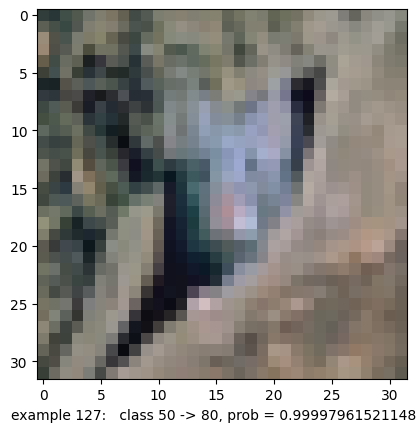

In [87]:
wrong_probs = []

for inputs, targets in val_loader:
    inputs, targets = inputs.to(device), targets.to(device)
    outputs = regnetx_3_2_pretrained(inputs)
    probabilities = torch.softmax(outputs, dim=1)
    max_probs, predictions = torch.max(probabilities, dim=1)
    print(max_probs, predictions)
        
    for example_id in range(len(inputs)):
        if targets[example_id] != predictions[example_id]:
            wrong_probs.append(max_probs[example_id])
            
            inputs, targets = inputs.to(torch.device("cpu")), targets.to(torch.device("cpu"))
            image = inputs[example_id].numpy().transpose(1, 2, 0)
            mean = [0.5071, 0.4867, 0.4408]
            std = [0.2675, 0.2565, 0.2761]
            image = std * image + mean
            image = np.clip(image, 0, 1)
            
            plt.imshow(image)
            plt.xlabel(f"example {example_id}:   class {targets[example_id]} -> {predictions[example_id]}, prob = {max_probs[example_id]}")
            plt.savefig(f"/home/user/Desktop/ML_homeworks_magistracy/task_files_2/wrong_examples/{example_id}")
    break
print("Max probability on wrong class:", max(wrong_probs))

## Итоговое сравнение методов

### Таблица сравнения показателей результативности методов

| Метод (до)обучения | Исходная точность модели (%, test) | Точность модели после обучения (%, test/train) | Расписание обучения (эпохи) | Суммарное количество эпох | Длительность эпохи (сек) |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Стандартное обучение** | ~1 | 47.43 / 100 | 100 | 100 | - |
| **Итеративная аугментация** | 2.03 | **57.34** / **100** | 5 итераций: 10+10* | 100 | 144-150 |
| **Итеративная разморозка слоёв** | 2.29 | 33.02 / 93.52 |  50+50** | 100 |  **128-150** |
| **Псевдолейблинг** | 57.34 | 57.37 / 60.76 | 20*** | 120 | 38-43 |

Заметки к расписаниям:
- (*) - обучение + finetuning
- (**) - замороженная до последнего fc-слоя сеть + линейное расписание разморозки от поверхностных к глубоким слоям
- (***) - только finetuning

### Лидирующие методы

Лучшие результаты по следующим параметрам показали следующие методы обучения: 
- скорость обучения (точность на train и скорость роста метрики) - **итеративная аугментация**,
- обобщающая способность - **итеративная аугментация**,
- время прохождения эпохи и суммарное время обучения - **итеративная разморозка слоев** (за счет разного количества обучаемых параметров на разных этапах).

Результаты **псевдолейблинга** как метода дообучения незначительны (0.03%) и могут быть индуцированы шумом.